# Pipeline actuel vs `pyDMD` / BOPDMD -- rang 6, 3/4 centraux x moitie superieure de la choroide

Compare, sur **UNE** condition et **UNE SEULE** matrice d'entree, deux facons
d'extraire le pouls choroidien d'une video OCT recalee :

| | **A. Pipeline actuel** | **B. BOPDMD (`pyDMD`)** |
|---|---|---|
| decomposition | SVD tronquee (`project_into_separable_components`) | Optimized DMD par projection variable (`BOPDMD`) |
| modes temporels | vecteurs singuliers gauches `U*S`, **non parametriques** | $b_k e^{\lambda_k t}$, **exponentielles complexes imposees** |
| modes spatiaux | `V`, **reels** | $\varphi_k$, **complexes** (module + phase) |
| pouls retenu | combinaison lineaire des composantes, poids optimises pour concentrer la puissance Lomb-Scargle dans la bande cardiaque (`OptimizedSpectralCombination`) | mode dont $\mathrm{Im}(\lambda_k)/2\pi$ est le plus proche de la HR |
| frequence | lue *a posteriori* (Lomb-Scargle / Hilbert) | **portee par $\lambda_k$**, sortie directe de l'ajustement |
| horodatages non uniformes | geres (Lomb-Scargle, puis interpolation avant le passe-bande) | geres nativement (`fit(X, t)` prend le vrai `t`) |
| amortissement | aucun modele | $\mathrm{Re}(\lambda_k)$ |

**Ce que le notebook affiche**, dans l'ordre demande : les traces d'entree
(section 1), les modes spatiaux ET temporels des deux methodes (section 5), le
pouls retenu par chacune (section 6), puis la phase et le rythme cardiaque
instantane (section 7).

## Choix arretes avant de commencer

- **Condition** : `02_210721001 / 210721001before_rigidity / 210721001before_rigidity_OD`.
- **ROI restreinte** : `col_frac=(0.125, 0.875)` -- les **3/4 centraux** des
  A-scans -- et `row_frac=(0.0, 0.5)` -- la **moitie superieure** de l'epaisseur
  choroidienne, mesuree A-scan par A-scan. Ligne 0 etant le haut de la frame,
  cette moitie est la moitie **interne** : cote Bruch / choriocapillaire, la ou
  la pulsation est attendue la plus forte. Les bords lateraux, eux, sont ceux
  ou le recalage est le moins fiable.
- **Un pixel = une trace** : `block_sizes=(1,)`, pas de multiresolution. Le
  pipeline de production utilise `block_sizes=(1,2,3,4,5)`, ce qui met les
  memes pixels cinq fois dans la matrice a des echelles differentes ; ici on
  veut des colonnes independantes pour que la SVD et la DMD voient exactement
  la meme chose.
- **Normalisation par frame conservee** (`normalized_signal()` : division de
  chaque frame par sa moyenne spatiale) -- elle retire la derive de gain /
  illumination commune a toute la ROI.
- **Moyenne temporelle retiree par pixel**, comme demande : sans ca la SVD
  depense son premier triplet singulier sur l'image moyenne (verifie en
  section 1.3), et la DMD un $\lambda$ a frequence nulle.
- **Chaque methode a son rang** : le pipeline tourne a son **rang de
  production, 100**, et BOPDMD au **rang 6** demande. Ce n'est volontairement
  pas une comparaison a rang egal -- a rang 6 le pipeline echoue (son critere
  de candidature rejette tout, cf. section 3), donc le comparer la n'apprend
  rien sur la methode. On compare chaque methode dans le regime ou elle
  fonctionne. La section 4 verifie par `fit_econ` que les deux voient bien le
  meme sous-espace de tete.

## Resultat a connaitre d'avance

`BOPDMD(svd_rank=6, num_trials=0, eig_constraints={"conjugate_pairs"})` avec son
**initialisation par defaut ne trouve pas le pouls** : elle converge sur la
derive basse frequence (quelques BPM). Il faut lui fournir un `init_alpha`
physiologique (harmoniques de la HR) pour qu'elle verrouille le fondamental. La
section 4 monte cette echelle en trois barreaux au lieu de masquer l'echec --
c'est le principal enseignement de la comparaison.

Attention, `varpro` emet son avertissement de non-convergence dans **les trois**
configurations, y compris celle qui trouve le bon resultat : cet avertissement
ne discrimine rien ici, il ne faut pas s'en servir comme critere de qualite.

## 0. Environnement, chemins, chargement

`pyDMD` n'est pas une dependance du package : decommenter la ligne `%pip` si
l'import echoue.

In [1]:
# %pip install pydmd
import pydmd
from pydmd import BOPDMD

print("pydmd :", pydmd.__file__)

pydmd : C:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\pydmd\__init__.py


In [2]:
from pathlib import Path
import csv
import re
import time
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.signal import hilbert, medfilt

from ocularrigidity.motion.filters._1d import spatio_temporal_filter
from ocularrigidity.motion.projection._1d import project_into_separable_components
from ocularrigidity.motion.pulsation import (
    CardiacBand,
    PixelTraceConfig,
    PixelTraceSource,
)
from ocularrigidity.motion.pulsation.phase import (
    OptimizedSpectralCombination,
    SpectralCombinationConfig,
)
from ocularrigidity.motion.pulsation.rate import (
    LombScargleConfig,
    LombScargleRateEstimator,
    lomb_scargle_power,
)
from ocularrigidity.motion.pulsation.traces import Traces
from ocularrigidity.motion.video_timeline_aligner import VideoTimelineAligner
from ocularrigidity.scripts.one_cycle.astronauts import _prepared_registrator
from ocularrigidity.scripts.registration.astronauts import load_ordered_oct_series

# --- Condition (memes chemins que compute_one_cycle_pixel_svd.py) ------------
PATH_GENERAL = Path("E:/SANSORI")                  # arborescence brute
SEGVAR_ROOT = Path("E:/NASA_Rigidity/SegmentationVariations")
MASK_VARIANT = "model1_scale_1.0"

SUBJECT = "210721001"      # -> E:/SANSORI/<NN>_210721001/...
MOMENT_KEY = "before"      # "before" | "after"
EYE = "OD"
REPLICAT = 1               # 1 = premier enregistrement disponible de cet oeil

# --- Entree commune aux deux methodes ---------------------------------------
# ROI restreinte : 3/4 CENTRAUX des A-scans, MOITIE SUPERIEURE de l'epaisseur.
# `col_frac` s'applique une fois, globalement, a la boite englobante en x de la
# ROI. `row_frac` s'applique PAR A-scan, a l'etendue en lignes de CETTE colonne
# dans la ROI -- pas une bande de lignes fixe : la choroide n'a ni la meme
# epaisseur ni la meme profondeur d'un A-scan a l'autre (cf. la pente marquee
# de la Bruch sur l'image moyenne). Ligne 0 = haut de la frame, donc la moitie
# "superieure" est la moitie INTERNE, cote Bruch / choriocapillaire.
COL_FRAC = (0.125, 0.875)     # 3/4 centraux de l'etendue d'A-scans
ROW_FRAC = (0.0, 0.5)         # moitie superieure (interne) de l'epaisseur locale
BLOCK_SIZES = (1,)            # un pixel = une trace (pas de multiresolution)
NORMALIZE_PER_FRAME = True    # normalized_signal() : / moyenne spatiale de la frame
REMOVE_TIME_MEAN = True       # - moyenne temporelle par pixel

RANK_SVD = 100                # rang du pipeline (son rang de production)
RANK_DMD = 6                  # rang de BOPDMD
N_SHOW = 6                    # nb de composantes SVD detaillees en plus des retenues

# --- Bande cardiaque ---------------------------------------------------------
DIAG_BPM_RANGE = (20.0, 240.0)    # grille LARGE, pour les periodogrammes
BAND_FRAC = 0.2                   # bande de SCORE : HR +/- 20 %

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE)

C:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0812 19:00:08.649000 265948 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


device = cuda


In [3]:
# --- Resolution de la condition ---------------------------------------------
def resolve_condition(subject, moment_key, eye, replicat=1, root=PATH_GENERAL):
    """(ASTRO, MOMENT, CONDITION) a partir de l'ID sujet.

    Deux pieges absorbes ici : le dossier "apres" s'appelle `post` et non
    `after`, et le suffixe de replicat est parfois absent (`..._OD`) parfois
    numerote (`..._OD1`).
    """
    astros = [p for p in sorted(root.iterdir())
              if p.is_dir() and re.fullmatch(rf"\d{{2}}_{subject}", p.name)]
    if not astros:
        dispo = ", ".join(p.name for p in sorted(root.iterdir()) if p.is_dir())
        raise ValueError(f"sujet {subject} absent ; disponibles : {dispo}")
    astro = astros[0]

    key = {"before": "before", "after": "post", "post": "post"}[str(moment_key).lower()]
    moment_dir = astro / f"{subject}{key}_rigidity"
    if not moment_dir.is_dir():
        dispo = ", ".join(p.name for p in sorted(astro.iterdir()) if p.is_dir())
        raise ValueError(f"{moment_dir.name} absent ; disponibles : {dispo}")

    def _rep(p):
        s = re.search(r"(\d*)$", p.name).group(1)
        return int(s) if s else 0

    conds = sorted((p for p in moment_dir.iterdir()
                    if p.is_dir() and re.search(rf"_{eye}\d*$", p.name)), key=_rep)
    if not 1 <= replicat <= len(conds):
        noms = ", ".join(p.name.rsplit("_", 1)[-1] for p in conds)
        raise ValueError(f"replicat {replicat} hors bornes ({len(conds)} dispo : {noms})")
    return astro.name, moment_dir.name, conds[replicat - 1].name


def find_raw_dir(condition_dir: Path):
    for name in ("RawImages", "RawData"):
        d = condition_dir / name
        if d.is_dir():
            return d
    return None


def raw_timestamps_us(raw_dir: Path) -> np.ndarray:
    """SegmentationVariations n'ecrit pas de timestamp.txt : les horodatages
    sont recalcules depuis l'export XML Spectralis."""
    series = load_ordered_oct_series(raw_dir)
    return np.array(
        [int(round(s.acquisition_time.seconds_of_day * 1e6)) for s in series],
        dtype=np.int64,
    )


def read_hr(path_condi: Path) -> float:
    path_heartbeat = path_condi / "Data Files" / "visit_data.csv"
    if not path_heartbeat.exists():
        return float("nan")
    df = pd.read_csv(path_heartbeat, quoting=csv.QUOTE_NONE)
    return float(np.nanmean(pd.to_numeric(df["HR"], errors="coerce")))


ASTRO, MOMENT, CONDITION = resolve_condition(SUBJECT, MOMENT_KEY, EYE, REPLICAT)
print(f"{ASTRO} / {MOMENT} / {CONDITION}")

02_210721001 / 210721001before_rigidity / 210721001before_rigidity_OD


In [4]:
condi_dir = PATH_GENERAL / ASTRO / MOMENT / CONDITION
variant_root = SEGVAR_ROOT / MASK_VARIANT
frames_path = variant_root / "registered_frames" / ASTRO / MOMENT / CONDITION / "cube.mp4"
mask_path = variant_root / "registered_masks" / ASTRO / MOMENT / CONDITION / "mask.npz"
for p in (condi_dir, frames_path, mask_path):
    if not p.exists():
        raise FileNotFoundError(p)

registrator = _prepared_registrator(frames_path, mask_path, DEVICE, verbose=False)
raw_dir = find_raw_dir(condi_dir)
if raw_dir is None:
    raise FileNotFoundError(f"RawImages/RawData absent : {condi_dir}")
ts_us = raw_timestamps_us(raw_dir)
if registrator.registered_frames.shape[0] != ts_us.size:
    raise ValueError(f"frames ({registrator.registered_frames.shape[0]}) "
                     f"!= horodatages ({ts_us.size})")

aligner = VideoTimelineAligner(registrator, ts_us)
t = aligner.timestamps_seconds     # (T,) horodatages REELS, non uniformes, t[0] = 0
u_time = aligner.uniform_time      # grille uniforme (exigee par le passe-bande FIR)
hr = read_hr(condi_dir)
f0 = hr / 60.0
band = CardiacBand(expected_bpm=hr if np.isfinite(hr) else None,
                   expected_bpm_band_frac=BAND_FRAC)

dt = np.diff(t)
print(f"video       : {registrator.registered_frames.shape}  ({t[-1] - t[0]:.1f} s)")
print(f"fs          : {aligner.fs:.2f} Hz   (dt reel min/med/max = "
      f"{dt.min():.3f} / {np.median(dt):.3f} / {dt.max():.3f} s)")
print(f"grille unif : {u_time.size} echantillons")
print(f"HR (visit_data.csv) : {hr:.0f} BPM = {f0:.3f} Hz  ->  "
      f"~{(t[-1] - t[0]) * f0:.0f} cycles dans l'enregistrement")
print(f"bande de score      : {band.effective_bpm_range[0]:.1f} - "
      f"{band.effective_bpm_range[1]:.1f} BPM")
if dt.max() > 3 * np.median(dt):
    print(f"\n/!\\ trou temporel de {dt.max():.2f} s : les horodatages ne sont PAS "
          f"uniformes.\n    Lomb-Scargle (pipeline) et BOPDMD (qui recoit `t` "
          f"explicitement) le gerent tous les deux ;\n    seul le passe-bande FIR "
          f"exige une interpolation prealable.")

video       : (401, 496, 768)  (28.5 s)
fs          : 17.86 Hz   (dt reel min/med/max = 0.022 / 0.056 / 1.350 s)
grille unif : 509 echantillons
HR (visit_data.csv) : 42 BPM = 0.700 Hz  ->  ~20 cycles dans l'enregistrement
bande de score      : 33.6 - 50.4 BPM

/!\ trou temporel de 1.35 s : les horodatages ne sont PAS uniformes.
    Lomb-Scargle (pipeline) et BOPDMD (qui recoit `t` explicitement) le gerent tous les deux ;
    seul le passe-bande FIR exige une interpolation prealable.


## 1. Les donnees d'entree pour pyDMD -- les traces

Une seule matrice `X`, `(T, N)`, servie **telle quelle** aux deux methodes
(pyDMD la recoit transposee, sa convention etant `(espace, temps)`). Trois
etapes, chacune tracee ci-dessous :

1. `raw_signal()` -> `sig0` : intensite brute, une colonne par pixel de la ROI.
   La ROI est l'intersection du masque choroidien sur **toutes** les frames --
   c'est ce qui garantit un jeu de pixels fixe, donc une matrice sans trou --
   puis restreinte aux **3/4 centraux** des A-scans et, dans chacun d'eux, a la
   **moitie superieure** de son epaisseur propre (`col_frac` / `row_frac`).
2. `normalized_signal()` -> `sig0n` : chaque frame divisee par sa moyenne
   spatiale, ce qui retire la derive de gain / illumination **commune**.
3. `X = sig0n - moyenne temporelle par pixel` -> retire l'image moyenne.

In [5]:
source = PixelTraceSource(
    registrator,
    aligner,
    PixelTraceConfig(
        band=band,
        col_frac=COL_FRAC,
        row_frac=ROW_FRAC,
        block_sizes=BLOCK_SIZES,
        verbose=True,
    ),
)

sig0 = source.raw_signal().astype(np.float64)                        # (T, N) brut
sig0n = source.normalized_signal().astype(np.float64) if NORMALIZE_PER_FRAME else sig0
X = sig0n - sig0n.mean(axis=0, keepdims=True) if REMOVE_TIME_MEAN else sig0n
roi = source.base_roi                                                # (H, W) bool

T, N = X.shape
print(f"sig0  {sig0.shape}   min={sig0.min():.3f} med={np.median(sig0):.3f} "
      f"max={sig0.max():.3f}")
print(f"sig0n moyenne spatiale par frame : {sig0n.mean(axis=1).min():.6f} .. "
      f"{sig0n.mean(axis=1).max():.6f}   (plate = 1 par construction)")
print(f"X     {X.shape}   {X.nbytes / 1e6:.0f} Mo   "
      f"|moyenne temporelle| max = {np.abs(X.mean(axis=0)).max():.2e}")
print(f"ROI   {int(roi.sum())} pixels sur {roi.size} "
      f"({roi.sum() / roi.size:.1%} de la frame)")
print(f"NaN   {int(np.isnan(X).sum())}")

sig0  (401, 10148)   min=0.000 med=3.018 max=7.614
sig0n moyenne spatiale par frame : 1.000000 .. 1.000000   (plate = 1 par construction)
X     (401, 10148)   33 Mo   |moyenne temporelle| max = 4.64e-16
ROI   10148 pixels sur 380928 (2.7% de la frame)
NaN   0


In [6]:
# --- Helpers partages (memes conventions que notebook/test_norm_int.ipynb) ---
# `roi` est deja restreinte par col_frac/row_frac ; `roi_full` est le masque
# choroidien complet (intersection temporelle, sans restriction), garde pour
# montrer en 1.1 ce que la restriction retire.
roi_full = registrator.registered_masks.astype(bool).all(axis=0)

_rows = np.where(roi.any(axis=1))[0]
_cols = np.where(roi.any(axis=0))[0]
_BOX = (slice(_rows.min(), _rows.max() + 1), slice(_cols.min(), _cols.max() + 1))

# Boite englobante du masque COMPLET, pour la vue d'ensemble de 1.1.
_rowsF = np.where(roi_full.any(axis=1))[0]
_colsF = np.where(roi_full.any(axis=0))[0]
_BOX_FULL = (slice(_rowsF.min(), _rowsF.max() + 1),
             slice(_colsF.min(), _colsF.max() + 1))
print(f"masque complet : {int(roi_full.sum())} pixels  ->  ROI restreinte : "
      f"{int(roi.sum())} pixels ({roi.sum() / roi_full.sum():.1%})")


def as_image(values):
    """Remet un vecteur (N,) a sa place dans le plan (H, W), recadre sur la
    boite englobante de la ROI. Hors ROI -> NaN."""
    img = np.full(roi.shape, np.nan, dtype=float)
    img[roi] = np.asarray(values, dtype=float)
    return img[_BOX]


# Grille de frequences de DIAGNOSTIC, sur-echantillonnee x5 comme
# LombScargleRateEstimator.score.
_df = 1.0 / (5.0 * (t[-1] - t[0]))
freqs = np.arange(DIAG_BPM_RANGE[0] / 60.0, DIAG_BPM_RANGE[1] / 60.0 + _df, _df)
bpm_axis = freqs * 60.0
in_band = (np.abs(bpm_axis - hr) <= BAND_FRAC * hr if np.isfinite(hr)
           else (bpm_axis >= 30.0) & (bpm_axis <= 180.0))


def spectrum(y):
    """Lomb-Scargle d'une trace unique (centree), sur les horodatages REELS."""
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(y)
    if ok.sum() < 8:
        return np.zeros_like(freqs)
    return lomb_scargle_power(t[ok], y[ok] - y[ok].mean(), freqs)


def band_score(y):
    """(fraction de puissance en bande, BPM du pic) d'une trace."""
    P = spectrum(y)
    return float(P[in_band].sum() / (P.sum() + 1e-12)), float(bpm_axis[P.argmax()])


def mark_hr(ax, label=True):
    if np.isfinite(hr):
        ax.axvline(hr, color="C1", lw=1.4, ls="--",
                   label=f"HR = {hr:.0f} BPM" if label else None)
        ax.axvspan(bpm_axis[in_band].min(), bpm_axis[in_band].max(),
                   color="C1", alpha=0.12, lw=0)


def z(y):
    """Trace reduite : les amplitudes ne sont pas comparables d'une methode a
    l'autre (valeurs singulieres et |b_k| sont a des echelles arbitraires),
    seules les FORMES le sont."""
    y = np.asarray(y, dtype=float)
    return (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)


mean_frame = registrator.registered_frames.mean(axis=0)
RNG = np.random.default_rng(0)
idx_plot = np.sort(RNG.choice(N, size=6, replace=False))
idx_spec = np.sort(RNG.choice(N, size=min(400, N), replace=False))
print("traces suivies :", idx_plot.tolist())

masque complet : 25755 pixels  ->  ROI restreinte : 10148 pixels (39.4%)
traces suivies : [415, 2737, 3123, 5185, 6461, 8627]


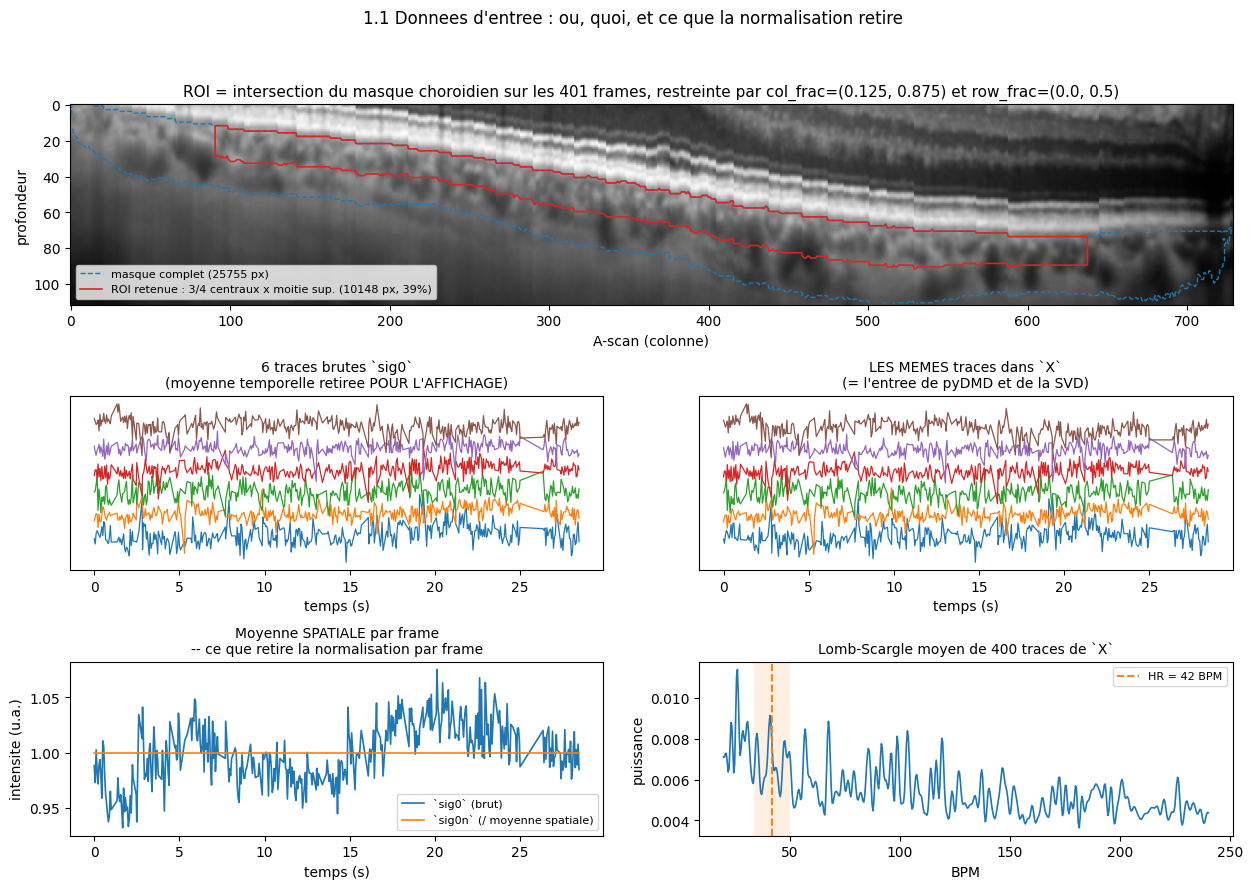

In [7]:
# --- 1.1 Ou sont les traces, et a quoi elles ressemblent ---------------------
fig = plt.figure(figsize=(15, 9.5))
gs = fig.add_gridspec(3, 2, height_ratios=[1.15, 1.0, 1.0], hspace=0.5, wspace=0.18)

ax = fig.add_subplot(gs[0, :])
ax.imshow(mean_frame[_BOX_FULL], cmap="gray", aspect="auto")
ax.contour(roi_full[_BOX_FULL].astype(float), levels=[0.5], colors="C0",
           linewidths=1.0, linestyles="--")
ax.contour(roi[_BOX_FULL].astype(float), levels=[0.5], colors="C3", linewidths=1.2)
ax.plot([], [], color="C0", ls="--", lw=1.0,
        label=f"masque complet ({int(roi_full.sum())} px)")
ax.plot([], [], color="C3", lw=1.2,
        label=f"ROI retenue : 3/4 centraux x moitie sup. ({int(roi.sum())} px, "
              f"{roi.sum() / roi_full.sum():.0%})")
ax.legend(fontsize=8, loc="lower left")
ax.set_title(f"ROI = intersection du masque choroidien sur les {T} frames, "
             f"restreinte par col_frac={COL_FRAC} et row_frac={ROW_FRAC}",
             fontsize=11)
ax.set_xlabel("A-scan (colonne)")
ax.set_ylabel("profondeur")

ax = fig.add_subplot(gs[1, 0])
vals = sig0[:, idx_plot] - sig0[:, idx_plot].mean(axis=0, keepdims=True)
step = 3.0 * np.median(vals.std(axis=0)) + 1e-9
for k in range(vals.shape[1]):
    ax.plot(t, vals[:, k] + k * step, lw=0.9)
ax.set_title("6 traces brutes `sig0`\n(moyenne temporelle retiree POUR L'AFFICHAGE)",
             fontsize=10)
ax.set_xlabel("temps (s)")
ax.set_yticks([])

ax = fig.add_subplot(gs[1, 1])
vals = X[:, idx_plot]
step = 3.0 * np.median(vals.std(axis=0)) + 1e-9
for k in range(vals.shape[1]):
    ax.plot(t, vals[:, k] + k * step, lw=0.9)
ax.set_title("LES MEMES traces dans `X`\n(= l'entree de pyDMD et de la SVD)",
             fontsize=10)
ax.set_xlabel("temps (s)")
ax.set_yticks([])

ax = fig.add_subplot(gs[2, 0])
ax.plot(t, sig0.mean(axis=1) / sig0.mean(), lw=1.2, label="`sig0` (brut)")
ax.plot(t, sig0n.mean(axis=1), lw=1.2, label="`sig0n` (/ moyenne spatiale)")
ax.set_title("Moyenne SPATIALE par frame\n-- ce que retire la normalisation par frame",
             fontsize=10)
ax.set_xlabel("temps (s)")
ax.set_ylabel("intensite (u.a.)")
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[2, 1])
P_mean = np.mean([spectrum(X[:, j]) for j in idx_spec], axis=0)
ax.plot(bpm_axis, P_mean, lw=1.2, color="C0")
mark_hr(ax)
ax.set_title(f"Lomb-Scargle moyen de {idx_spec.size} traces de `X`", fontsize=10)
ax.set_xlabel("BPM")
ax.set_ylabel("puissance")
ax.legend(fontsize=8)

fig.suptitle("1.1 Donnees d'entree : ou, quoi, et ce que la normalisation retire",
             fontsize=12)
plt.show()

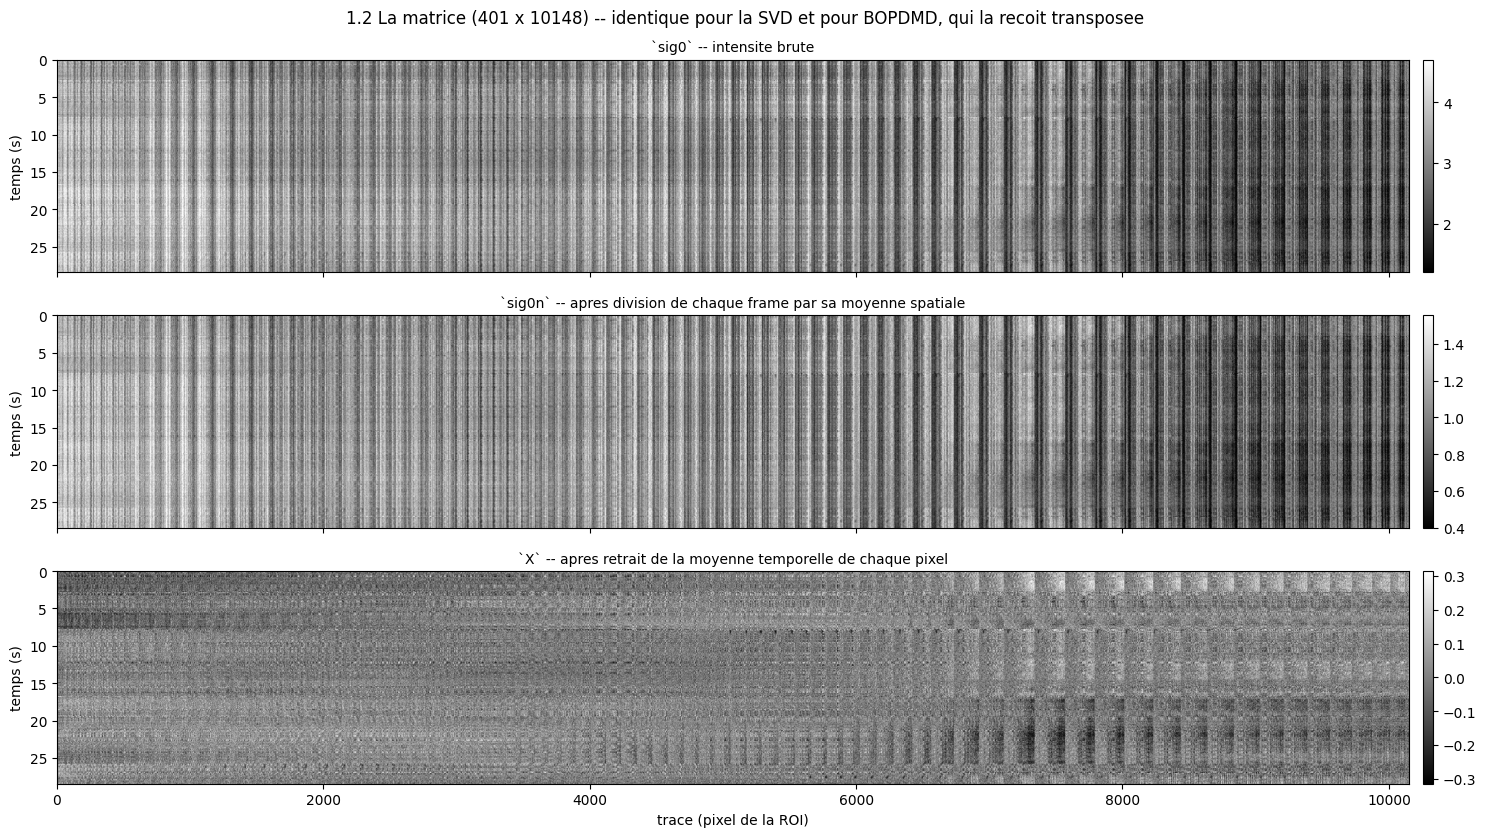

In [8]:
# --- 1.2 La matrice servie aux deux methodes ---------------------------------
# Les colonnes suivent l'ordre C de `roi` : profondeur d'abord, donc l'axe
# horizontal balaye la choroide de gauche a droite, A-scan par A-scan.
fig, axes = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True)
for ax, (mat, name) in zip(axes, [
    (sig0, "`sig0` -- intensite brute"),
    (sig0n, "`sig0n` -- apres division de chaque frame par sa moyenne spatiale"),
    (X, "`X` -- apres retrait de la moyenne temporelle de chaque pixel"),
]):
    lo, hi = np.percentile(mat, [1, 99])
    im = ax.imshow(mat, cmap="gray", aspect="auto", vmin=lo, vmax=hi,
                   extent=[0, N, t[-1], t[0]])
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("temps (s)")
axes[-1].set_xlabel("trace (pixel de la ROI)")
fig.suptitle(f"1.2 La matrice ({T} x {N}) -- identique pour la SVD et pour BOPDMD, "
             "qui la recoit transposee", fontsize=12)
fig.tight_layout()
plt.show()

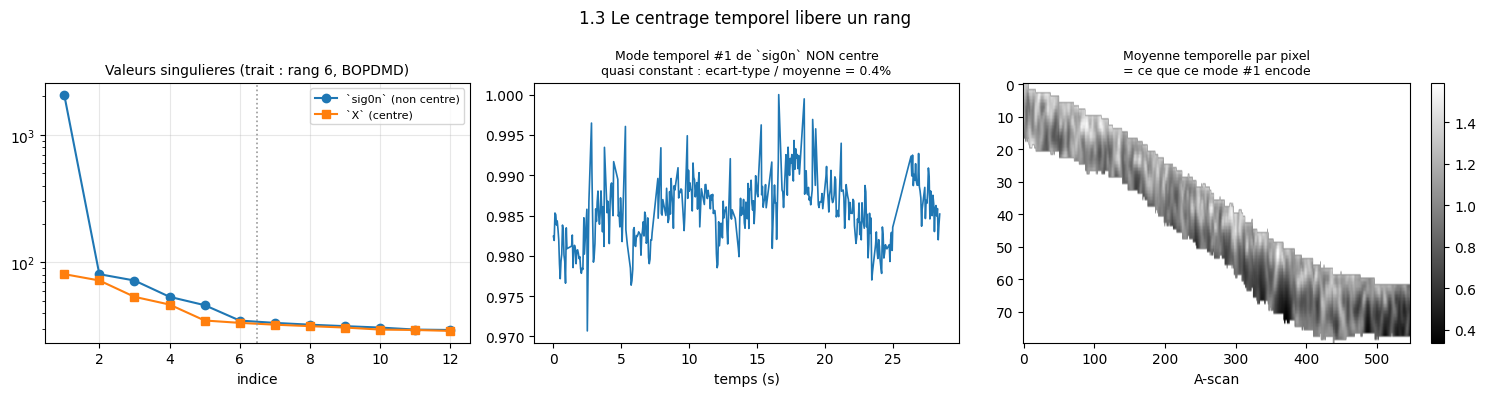

part de variance du 1er triplet : non centre 98.5%   |   centre 10.2%


In [9]:
# --- 1.3 Pourquoi retirer la moyenne temporelle ------------------------------
# Sans centrage, le premier triplet singulier code l'image moyenne : mode
# spatial = la choroide elle-meme, mode temporel quasi constant. Il ne porte
# aucune pulsation mais consomme un des 6 rangs disponibles -- et cote DMD, il
# donne un lambda a frequence ~0.
s_raw = np.linalg.svd(sig0n, compute_uv=False)
s_cen = np.linalg.svd(X, compute_uv=False)
U_raw, _ = project_into_separable_components(
    sig0n, method="svd", n_components=3, normalize=False, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
k = 12
axes[0].semilogy(np.arange(1, k + 1), s_raw[:k], "o-", label="`sig0n` (non centre)")
axes[0].semilogy(np.arange(1, k + 1), s_cen[:k], "s-", label="`X` (centre)")
axes[0].axvline(RANK_DMD + 0.5, color="0.6", ls=":", lw=1.2)
axes[0].set_title(f"Valeurs singulieres (trait : rang {RANK_DMD}, BOPDMD)",
                  fontsize=10)
axes[0].set_xlabel("indice")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(t, U_raw[:, 0] / np.abs(U_raw[:, 0]).max(), lw=1.2)
axes[1].set_title("Mode temporel #1 de `sig0n` NON centre\n"
                  f"quasi constant : ecart-type / moyenne = "
                  f"{U_raw[:, 0].std() / abs(U_raw[:, 0].mean()):.1%}", fontsize=9)
axes[1].set_xlabel("temps (s)")

im = axes[2].imshow(as_image(sig0n.mean(axis=0)), cmap="gray", aspect="auto")
fig.colorbar(im, ax=axes[2], fraction=0.04)
axes[2].set_title("Moyenne temporelle par pixel\n= ce que ce mode #1 encode",
                  fontsize=9)
axes[2].set_xlabel("A-scan")
fig.suptitle("1.3 Le centrage temporel libere un rang", fontsize=12)
fig.tight_layout()
plt.show()

print(f"part de variance du 1er triplet : "
      f"non centre {s_raw[0] ** 2 / (s_raw ** 2).sum():.1%}   |   "
      f"centre {s_cen[0] ** 2 / (s_cen ** 2).sum():.1%}")

## 2. Methode A -- pipeline actuel : SVD rang 100

`project_into_separable_components(X, method="svd", n_components=100,
normalize=False)`. `normalize=False` parce que `X` est **deja** centre
(section 1.3) : le laisser a `True` recentrerait une seconde fois -- sans effet
ici, mais trompeur a la lecture.

Sorties : `U` `(T, 100)` = `U*S`, les modes **temporels** ; `V` `(N, 100)`, les
modes **spatiaux**, reels.

Le periodogramme Lomb-Scargle de **chacun** des 100 vecteurs singuliers
temporels est calcule ici : c'est lui qui decide de toute la suite, puisque
`OptimizedSpectralCombination` selectionne ses candidates sur le pic et la
concentration de ce periodogramme. Les deux tableaux ci-dessous suffisent deja a
annoncer la couleur -- **les composantes de tete ne sont pas celles qui portent
le pouls**. La carte des 100 periodogrammes est en section 3.1, et le detail
composante par composante en 5.1, une fois qu'on sait lesquelles ont ete
retenues.

In [10]:
t0 = time.perf_counter()
U, V = project_into_separable_components(
    X, method="svd", n_components=RANK_SVD, normalize=False, random_state=0)
t_svd = time.perf_counter() - t0
S = np.linalg.norm(U, axis=0)          # valeurs singulieres (U renvoye vaut U*S)

# Periodogramme de CHAQUE vecteur singulier temporel : (F, RANK_SVD).
t0 = time.perf_counter()
P_svd = np.stack([spectrum(U[:, i]) for i in range(RANK_SVD)], axis=1)
t_per = time.perf_counter() - t0

peak_svd_comp = bpm_axis[P_svd.argmax(axis=0)]
frac_svd_comp = P_svd[in_band].sum(axis=0) / (P_svd.sum(axis=0) + 1e-12)
df_svd = pd.DataFrame({
    "sigma": S,
    "var_%": 100 * S ** 2 / (s_cen ** 2).sum(),
    "pic_BPM": peak_svd_comp,
    "en_bande_%": 100 * frac_svd_comp,
}).rename_axis("comp")

print(f"SVD rang {RANK_SVD} en {t_svd:.1f} s, {RANK_SVD} periodogrammes en "
      f"{t_per:.1f} s   (HR = {hr:.0f} BPM)")
print(f"variance cumulee des {RANK_SVD} composantes : "
      f"{100 * (S ** 2).sum() / (s_cen ** 2).sum():.1f} %")
print(f"composantes piquant DANS la bande {band.effective_bpm_range[0]:.0f}-"
      f"{band.effective_bpm_range[1]:.0f} BPM : "
      f"{int(((peak_svd_comp >= band.effective_bpm_range[0]) & (peak_svd_comp <= band.effective_bpm_range[1])).sum())}"
      f" sur {RANK_SVD}")

print(f"\n10 premieres composantes (par valeur singuliere) :")
display(df_svd.head(10).round(2))
print("10 composantes les plus concentrees dans la bande cardiaque :")
display(df_svd.nlargest(10, "en_bande_%").round(2))

SVD rang 100 en 0.2 s, 100 periodogrammes en 0.1 s   (HR = 42 BPM)
variance cumulee des 100 composantes : 68.5 %
composantes piquant DANS la bande 34-50 BPM : 36 sur 100

10 premieres composantes (par valeur singuliere) :


,sigma,var_%,pic_BPM,en_bande_%
comp,,,,
0,80.72,10.22,67.65,7.20
1,71.99,8.13,30.12,16.07
2,53.59,4.51,84.94,7.83
3,46.60,3.41,47.41,17.37
4,34.95,1.92,41.93,11.02
5,33.48,1.76,41.09,14.38
6,32.40,1.65,111.93,8.17
7,31.55,1.56,29.28,10.04
8,30.77,1.49,166.33,4.77


10 composantes les plus concentrees dans la bande cardiaque :


,sigma,var_%,pic_BPM,en_bande_%
comp,,,,
23,19.01,0.57,41.51,32.11
25,18.22,0.52,41.51,27.64
20,22.17,0.77,41.93,23.13
42,13.25,0.28,44.88,21.38
28,15.57,0.38,41.09,20.01
55,12.27,0.24,34.76,19.09
29,15.40,0.37,44.46,18.84
47,12.79,0.26,44.88,18.57
58,12.06,0.23,38.98,18.49


## 3. Methode A (suite) -- le pouls retenu par le pipeline

`OptimizedSpectralCombination` cherche les poids `w` (`||w||_2 = 1`) sur les
composantes **candidates** qui maximisent la puissance Lomb-Scargle en bande
moins la puissance hors bande, sommee sur 5 fenetres de 6 cycles.

Une composante n'est candidate que si (a) son propre pic tombe a moins de
`accept_tol_bpm` de la HR **et** (b) sa **concentration** spectrale depasse
`min_concentration` (0.15 par defaut) -- les deux se lisent directement sur la
carte de la section 2.1. Le seuil est descendu par paliers seulement si aucune
candidate ne passe, et le palier effectivement utilise est annonce ; a rang 100
le seuil nominal suffit.

> **Pourquoi il n'y a pas de pipeline a rang 6 ici.** Teste (mettre
> `RANK_SVD = 6` pour le reproduire), il refuse toute
> candidate au seuil nominal : sur 6 composantes issues de ~1e4 pixels, aucune
> n'atteint `min_concentration=0.15`. Il faut descendre a 0.10 pour obtenir un
> pouls, et ce pouls n'a que ~12 % de sa puissance en bande. Comparer les deux
> methodes a rang 6 mesurerait donc surtout un seuil mal adapte, pas la
> methode. Le pipeline reste a son rang de production.

In [11]:
# Bande LARGE pour le rate estimator : sa grille `freqs` sert aussi de grille
# hors-bande dans l'objectif (sinon le rapport a maximiser est degenere).
# `override_bpm` fixe la cible a la HR mesuree, sans re-estimation.
RATE_EST = LombScargleRateEstimator(
    LombScargleConfig(band=CardiacBand(bpm_range=DIAG_BPM_RANGE), verbose=False),
    override_bpm=float(hr),
)


def pipeline_pulse(U_, V_, tag, n_restarts=8, maxiter=200,
                   min_conc_ladder=(0.15, 0.10, 0.05, 0.0)):
    """SVD -> combinaison optimisee. Renvoie (pouls sur `t`, diagnostics)."""
    traces = Traces(
        values=np.asarray(U_, dtype=np.float64),
        uniform_time=t,
        kept_mask=np.ones(t.size, dtype=bool),
        gap_mask=np.zeros(t.size, dtype=bool),
        timestamps_seconds=t,
        mixing=np.asarray(V_, dtype=np.float64),
    )
    rate = RATE_EST.estimate(traces)
    for min_conc in min_conc_ladder:
        agg = OptimizedSpectralCombination(SpectralCombinationConfig(
            accept_tol_bpm=BAND_FRAC * hr,
            min_concentration=min_conc,
            max_candidates=min(12, U_.shape[1]),
            n_restarts=n_restarts, maxiter=maxiter, random_state=0,
            window_n_cycles=6, n_windows=5,
        ))
        t0 = time.perf_counter()
        try:
            y = agg.aggregate(traces, rate)
        except ValueError as exc:
            print(f"  [{tag}] min_concentration={min_conc:.2f} -> REFUS : {exc}")
            continue
        elapsed = time.perf_counter() - t0
        res = agg.last_result
        print(f"  [{tag}] min_concentration={min_conc:.2f} -> OK en {elapsed:.1f} s : "
              f"{res.selected_indices.size} candidates "
              f"{res.selected_indices.tolist()}, objectif {res.objective:+.4f}")
        return y, {"result": res, "rate": rate, "min_conc": min_conc,
                   "elapsed": elapsed}
    raise RuntimeError(f"[{tag}] aucune combinaison possible, meme sans seuil de "
                       "concentration")


# --- Reference de SIGNE, commune aux deux methodes ---------------------------
# `sig0n` a une moyenne spatiale plate par construction (= 1 a chaque frame) :
# sa moyenne ne porte plus aucun signe. On prend donc la moyenne des traces
# BRUTES centrees en temps, qui conserve la composante commune a toute la ROI.
sign_ref = (sig0 - sig0.mean(axis=0, keepdims=True)).mean(axis=1)


def phasor_at_f0(y):
    """Amplitude complexe de `y` a la frequence cardiaque, sur les horodatages
    reels."""
    yc = np.asarray(y, dtype=float)
    yc = yc - yc.mean()
    return (yc @ np.cos(2 * np.pi * f0 * t)) + 1j * (yc @ np.sin(2 * np.pi * f0 * t))


_ref_phasor = phasor_at_f0(sign_ref)


def fix_sign(y, name):
    """Le signe d'une SVD comme celui d'un mode DMD est arbitraire : on le fixe
    pour que le pouls soit EN PHASE avec `sign_ref`, sans quoi les formes des
    deux methodes ne sont pas superposables.

    La decision se prend en BANDE ETROITE -- sur le phaseur a f0, comme le fait
    `OptimizedSpectralCombination._initial_weights` -- et non sur la
    correlation large bande : `sign_ref` est domine par du bruit hors bande, sa
    correlation brute avec un pouls est de l'ordre de 0.05 et ne suffit pas a
    trancher une polarite. La correlation large bande reste affichee a titre de
    diagnostic.
    """
    y = np.asarray(y, dtype=float)
    c = np.corrcoef(y, sign_ref)[0, 1]
    aligned = float(np.real(phasor_at_f0(y) * np.conj(_ref_phasor)))
    sgn = -1.0 if aligned < 0 else 1.0
    print(f"  signe [{name}] : phaseur a f0 = {aligned:+.3g} "
          f"(corr large bande {c:+.3f})" + ("   -> retourne" if sgn < 0 else ""))
    return sgn * y, sgn


print(f"pipeline, rang {RANK_SVD} :")
y_svd, diag_svd = pipeline_pulse(U, V, f"rang {RANK_SVD}")
y_svd, sgn_svd = fix_sign(y_svd, f"SVD rang {RANK_SVD}")
frac_svd, peak_svd = band_score(y_svd)
selected = diag_svd["result"].selected_indices
weights = diag_svd["result"].weights
print(f"  pouls : pic {peak_svd:.1f} BPM, {frac_svd:.1%} de la puissance en bande")

# Motif spatial de la combinaison retenue : V[:, selected] @ w.
pattern_svd = sgn_svd * diag_svd["result"].spatial_pattern

print(f"\ncomposantes retenues et leur poids :")
display(pd.DataFrame({
    "comp": selected,
    "poids": weights,
    "sigma": S[selected],
    "pic_BPM": peak_svd_comp[selected],
    "en_bande_%": 100 * frac_svd_comp[selected],
}).set_index("comp").round(3))

pipeline, rang 100 :


  [rang 100] min_concentration=0.15 -> OK en 2.5 s : 7 candidates [20, 22, 23, 25, 29, 42, 55], objectif -0.8737
  signe [SVD rang 100] : phaseur a f0 = +23.8 (corr large bande +0.008)
  pouls : pic 41.5 BPM, 53.3% de la puissance en bande

composantes retenues et leur poids :


,poids,sigma,pic_BPM,en_bande_%
comp,,,,
20,0.257,22.166,41.929,23.129
22,-0.384,19.911,41.929,17.917
23,0.626,19.011,41.507,32.106
25,-0.594,18.221,41.507,27.635
29,0.171,15.402,44.459,18.843
42,-0.103,13.250,44.881,21.380
55,0.046,12.272,34.760,19.092


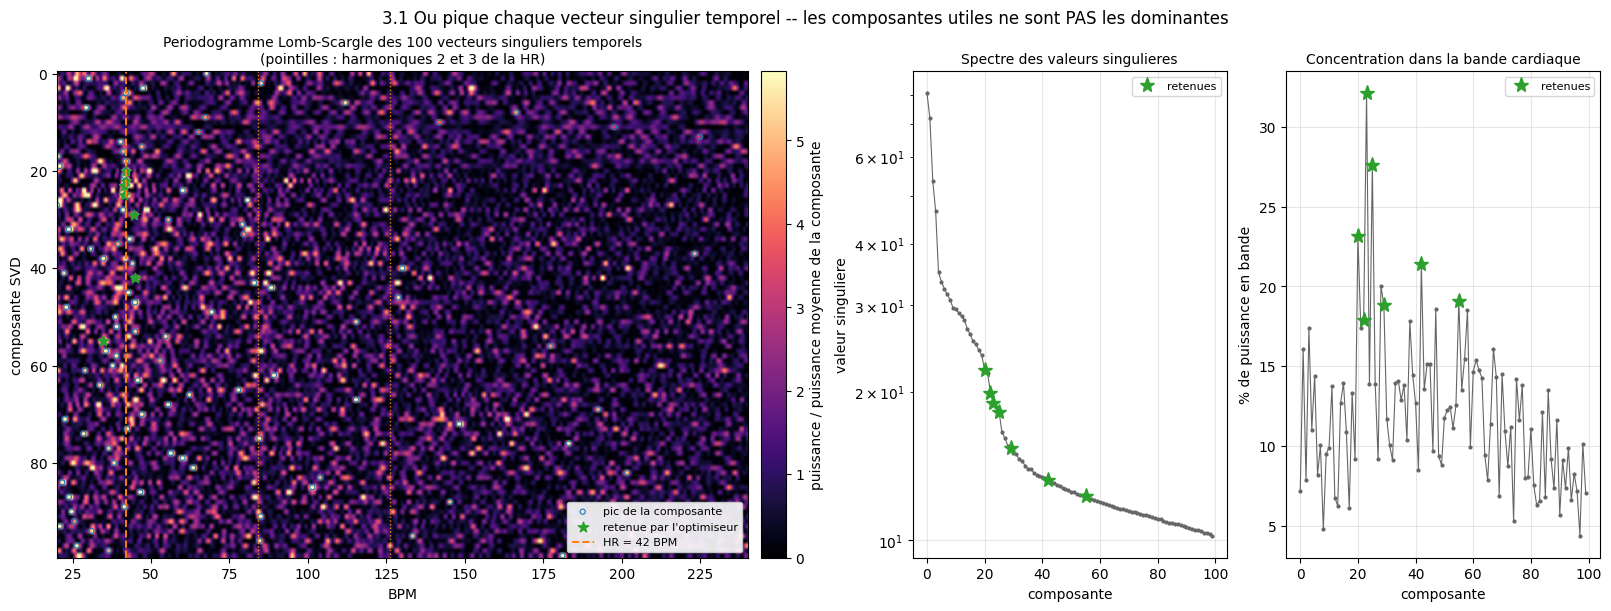

In [12]:
# --- 3.1 Les 100 periodogrammes d'un coup -------------------------------------
# Chaque ligne est normalisee par sa puissance MOYENNE, pas par son max : on
# affiche donc un "exces spectral" (1 = plancher de bruit de cette composante).
# Normaliser par le max aplatirait tout au niveau du bruit, les periodogrammes
# Lomb-Scargle d'un enregistrement de 28 s etant intrinsequement hachures.
Pn = P_svd / (P_svd.mean(axis=0, keepdims=True) + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [2.2, 1.0, 1.0]},
                         constrained_layout=True)

ax = axes[0]
im = ax.imshow(Pn.T, aspect="auto", cmap="magma", vmin=0,
               vmax=np.percentile(Pn, 99.5),
               extent=[bpm_axis[0], bpm_axis[-1], RANK_SVD - 0.5, -0.5])
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02,
             label="puissance / puissance moyenne de la composante")
ax.scatter(peak_svd_comp, np.arange(RANK_SVD), s=14, facecolor="none",
           edgecolor="C0", lw=0.8, label="pic de la composante")
ax.scatter(peak_svd_comp[selected], selected, s=60, marker="*", color="C2",
           label="retenue par l'optimiseur")
ax.axvline(hr, color="C1", lw=1.4, ls="--", label=f"HR = {hr:.0f} BPM")
for k in (2, 3):
    ax.axvline(k * hr, color="C1", lw=1.0, ls=":")
ax.set_xlabel("BPM")
ax.set_ylabel("composante SVD")
ax.set_title(f"Periodogramme Lomb-Scargle des {RANK_SVD} vecteurs singuliers "
             "temporels\n(pointilles : harmoniques 2 et 3 de la HR)", fontsize=10)
ax.legend(fontsize=8, loc="lower right", framealpha=0.9)

ax = axes[1]
ax.semilogy(np.arange(RANK_SVD), S, ".-", lw=0.8, ms=4, color="0.4")
ax.semilogy(selected, S[selected], "*", ms=11, color="C2", label="retenues")
ax.set_xlabel("composante")
ax.set_ylabel("valeur singuliere")
ax.set_title("Spectre des valeurs singulieres", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(np.arange(RANK_SVD), 100 * frac_svd_comp, ".-", lw=0.8, ms=4, color="0.4")
ax.plot(selected, 100 * frac_svd_comp[selected], "*", ms=11, color="C2",
        label="retenues")
ax.set_xlabel("composante")
ax.set_ylabel("% de puissance en bande")
ax.set_title("Concentration dans la bande cardiaque", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("3.1 Ou pique chaque vecteur singulier temporel -- les composantes "
             "utiles ne sont PAS les dominantes", fontsize=12)
plt.show()

## 4. Methode B -- BOPDMD rang 6

`BOPDMD.fit(X.T, t)` : la convention pyDMD est `(espace, temps)`, et `t` est le
vrai vecteur d'horodatages **non uniformes** -- l'optimized DMD par projection
variable n'exige aucun pas de temps constant, contrairement a la DMD exacte.

Trois configurations, toutes a `svd_rank=6`, `num_trials=0` :

| | `init_alpha` | `eig_constraints` |
|---|---|---|
| **B1** | defaut (regle du trapeze projetee) | `{"conjugate_pairs"}` |
| **B2** | $\lambda_k = -0.05 \pm 2i\pi k f_0$, $k = 1,2,3$ (HR et ses harmoniques) | `{"conjugate_pairs"}` |
| **B3** | idem B2 | `{"conjugate_pairs", "imag"}` -- $\mathrm{Re}(\lambda) = 0$ impose |

`conjugate_pairs` garantit que les valeurs propres vont par paires conjuguees,
donc que les modes reconstruits sont **reels** ; `imag` interdit en plus tout
amortissement, ce qui empeche la projection variable d'expliquer une modulation
d'amplitude du pouls par une exponentielle decroissante.

`varpro` avertit d'une non-convergence dans les trois cas -- y compris celui qui
donne le bon resultat. Cet avertissement ne dit rien de la qualite de
l'ajustement ici ; c'est le tableau de valeurs propres qui tranche.

In [13]:
def harmonic_init(rank, f0_hz, damping=-0.05):
    """Valeurs propres de depart : f0 et ses harmoniques, en paires conjuguees."""
    pairs = []
    for k in range(1, rank // 2 + 1):
        w = 2j * np.pi * f0_hz * k
        pairs += [damping + w, damping - w]
    if rank % 2:                       # rang impair : un mode purement reel de plus
        pairs.append(damping + 0j)
    return np.array(pairs[:rank])


def fit_bopdmd(tag, **kwargs):
    kwargs.setdefault("eig_constraints", {"conjugate_pairs"})
    kwargs.setdefault("varpro_opts_dict", {"maxiter": 200})
    bop = BOPDMD(svd_rank=RANK_DMD, num_trials=0, **kwargs)
    t0 = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        bop.fit(X.T, t)
        failed = any("converge" in str(c.message) for c in caught)
    elapsed = time.perf_counter() - t0
    # `eigs` est en TEMPS CONTINU (dX/dt = A X) : la frequence est Im(lambda)/2pi,
    # PAS log(lambda).imag/(2 pi dt) comme pour une DMD a temps discret.
    f_bpm = bop.eigs.imag / (2 * np.pi) * 60.0
    print(f"[{tag}] {elapsed:.1f} s"
          + ("   /!\\ varpro signale un echec de convergence" if failed
             else "   converge"))
    return {"tag": tag, "dmd": bop, "f_bpm": f_bpm, "growth": bop.eigs.real,
            "elapsed": elapsed, "converged": not failed}


init_alpha = harmonic_init(RANK_DMD, f0)
print("init_alpha (B2/B3) :",
      np.round(np.abs(init_alpha.imag) / (2 * np.pi) * 60, 1), "BPM\n")

variants = {}
variants["B1"] = fit_bopdmd("B1 defaut")
variants["B2"] = fit_bopdmd("B2 init=harmoniques", init_alpha=init_alpha)
variants["B3"] = fit_bopdmd("B3 init=harmoniques + imag", init_alpha=init_alpha,
                            eig_constraints={"conjugate_pairs", "imag"})

rows = []
for key, v in variants.items():
    for i in np.argsort(-np.abs(v["dmd"].amplitudes)):
        if v["f_bpm"][i] < 0:
            continue                          # une ligne par paire conjuguee
        rows.append({"variante": key, "f_BPM": v["f_bpm"][i],
                     "croissance_1/s": v["growth"][i],
                     "|b|": abs(v["dmd"].amplitudes[i]),
                     "ecart_a_HR_BPM": v["f_bpm"][i] - hr,
                     "f/HR": v["f_bpm"][i] / hr})
df_dmd = pd.DataFrame(rows)
print(f"\nValeurs propres (une ligne par paire conjuguee, HR = {hr:.0f} BPM) :")
display(df_dmd.round(3))

init_alpha (B2/B3) : [ 42.  42.  84.  84. 126. 126.] BPM



[B1 defaut] 1.1 s   /!\ varpro signale un echec de convergence


[B2 init=harmoniques] 1.7 s   /!\ varpro signale un echec de convergence


[B3 init=harmoniques + imag] 1.1 s   /!\ varpro signale un echec de convergence

Valeurs propres (une ligne par paire conjuguee, HR = 42 BPM) :


,variante,f_BPM,croissance_1/s,|b|,ecart_a_HR_BPM,f/HR
0,B1,5.196000,-0.508,8.801,-36.804001,0.124
1,B1,2.526000,0.047,0.931,-39.473999,0.060
2,B1,13.318000,0.107,0.082,-28.681999,0.317
3,B2,1.752000,0.007,1.770,-40.248001,0.042
4,B2,85.698997,-0.036,0.750,43.699001,2.040
5,B2,126.552002,-0.017,0.641,84.552002,3.013
6,B3,126.622002,0.000,0.531,84.622002,3.015
7,B3,40.674999,0.000,0.529,-1.325000,0.968
8,B3,85.804001,0.000,0.528,43.804001,2.043


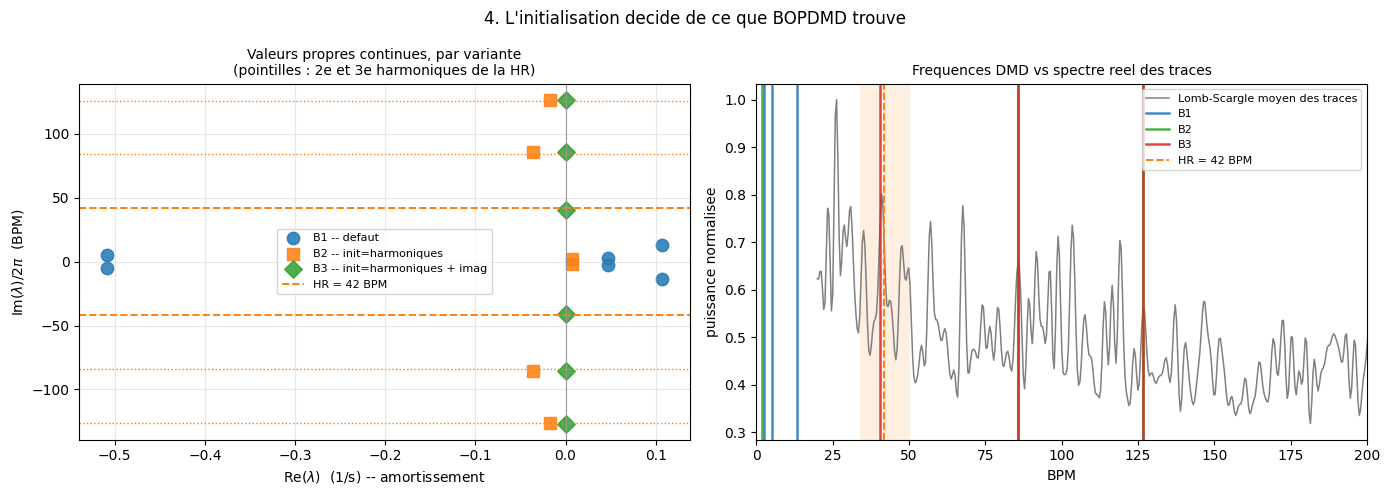

In [14]:
# --- Plan complexe : ce que chaque initialisation trouve ---------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (key, v), mk in zip(variants.items(), ["o", "s", "D"]):
    axes[0].scatter(v["growth"], v["f_bpm"], s=80, marker=mk, alpha=0.85,
                    label=f"{key} -- {v['tag'].split(' ', 1)[1]}")
axes[0].axhline(hr, color="C1", ls="--", lw=1.4, label=f"HR = {hr:.0f} BPM")
axes[0].axhline(-hr, color="C1", ls="--", lw=1.4)
for k in (2, 3):
    axes[0].axhline(k * hr, color="C1", ls=":", lw=1.0)
    axes[0].axhline(-k * hr, color="C1", ls=":", lw=1.0)
axes[0].axvline(0, color="0.6", lw=0.8)
axes[0].set_xlabel(r"$\mathrm{Re}(\lambda)$  (1/s) -- amortissement")
axes[0].set_ylabel(r"$\mathrm{Im}(\lambda) / 2\pi$  (BPM)")
axes[0].set_title("Valeurs propres continues, par variante\n"
                  "(pointilles : 2e et 3e harmoniques de la HR)", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(bpm_axis, P_mean / P_mean.max(), color="0.5", lw=1.1,
             label="Lomb-Scargle moyen des traces")
for (key, v), c in zip(variants.items(), ["C0", "C2", "C3"]):
    first = True
    for f_i in v["f_bpm"]:
        if f_i <= 0:
            continue
        axes[1].axvline(f_i, color=c, lw=1.8, alpha=0.85,
                        label=key if first else None)
        first = False
mark_hr(axes[1])
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("BPM")
axes[1].set_ylabel("puissance normalisee")
axes[1].set_title("Frequences DMD vs spectre reel des traces", fontsize=10)
axes[1].legend(fontsize=8)
fig.suptitle("4. L'initialisation decide de ce que BOPDMD trouve", fontsize=12)
fig.tight_layout()
plt.show()

In [15]:
# --- Variante retenue pour la suite ------------------------------------------
# Celle dont une frequence tombe le plus pres de la HR mesuree. Forcer un autre
# choix en mettant RETAINED = "B1" / "B2" / "B3".
RETAINED = None


def _closest_to_hr(v):
    pos = v["f_bpm"] > 0
    return np.min(np.abs(v["f_bpm"][pos] - hr)) if pos.any() else np.inf


if RETAINED is None:
    RETAINED = min(variants, key=lambda key: _closest_to_hr(variants[key]))
V_DMD = variants[RETAINED]
dmd = V_DMD["dmd"]
f_bpm = V_DMD["f_bpm"]

# Mode retenu = paire conjuguee dont la frequence positive est la plus proche
# de la HR mesuree.
cand = np.where(f_bpm > 0)[0]
k_dmd = int(cand[np.argmin(np.abs(f_bpm[cand] - hr))])
hr_dmd = float(f_bpm[k_dmd])
tau = abs(1.0 / V_DMD["growth"][k_dmd]) if V_DMD["growth"][k_dmd] else np.inf

print(f"variante retenue : {RETAINED} ({V_DMD['tag']})")
print(f"mode retenu      : #{k_dmd}")
print(f"  frequence      : {hr_dmd:.2f} BPM   (HR mesuree {hr:.0f} -> ecart "
      f"{hr_dmd - hr:+.2f} BPM)")
print(f"  amortissement  : Re(lambda) = {V_DMD['growth'][k_dmd]:+.4f} 1/s "
      f"(temps caracteristique {tau:.1f} s, pour {t[-1] - t[0]:.0f} s de video)")
print(f"  autres modes   : {np.round(np.sort(f_bpm[f_bpm > 0]), 1).tolist()} BPM")

variante retenue : B3 (B3 init=harmoniques + imag)
mode retenu      : #0
  frequence      : 40.68 BPM   (HR mesuree 42 -> ecart -1.32 BPM)
  amortissement  : Re(lambda) = +0.0000 1/s (temps caracteristique inf s, pour 28 s de video)
  autres modes   : [40.70000076293945, 85.80000305175781, 126.5999984741211] BPM


In [16]:
# --- Le meme sous-espace, servi a BOPDMD via fit_econ ------------------------
# `fit_econ(s, V, t)` accepte une SVD deja calculee. On lui donne les RANK_DMD
# premiers triplets de la SVD du pipeline (section 2) : X_pyDMD = X.T
# = V @ diag(S) @ (U/S).T, donc la base de projection est V[:, :r] (N, r) et les
# vecteurs singuliers droits sont les lignes de (U[:, :r]/S[:r]).T. C'est
# exactement le sous-espace de tete que BOPDMD se serait construit tout seul --
# si les deux ajustements coincident, l'ecart entre les methodes ne vient PAS
# d'une reduction differente.
r_ = RANK_DMD
bop_econ = BOPDMD(svd_rank=r_, num_trials=0,
                  eig_constraints=dmd.eig_constraints,
                  init_alpha=(None if RETAINED == "B1" else init_alpha),
                  proj_basis=np.asarray(V[:, :r_]), use_proj=True,
                  varpro_opts_dict={"maxiter": 200})
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bop_econ.fit_econ(S[:r_], (U[:, :r_] / S[:r_]).T, t)

f_fit = np.sort(f_bpm)
f_econ = np.sort(bop_econ.eigs.imag / (2 * np.pi) * 60.0)
ecart = float(np.max(np.abs(f_fit - f_econ)))
print(f"fit(X, t)     : {np.round(f_fit, 2).tolist()} BPM")
print(f"fit_econ(SVD) : {np.round(f_econ, 2).tolist()} BPM")
print(f"ecart maximal : {ecart:.3f} BPM")
print("\n-> " + ("les deux ajustements coincident : la SVD du pipeline et la SVD "
                 "interne de pyDMD\n   engendrent le meme sous-espace de rang "
                 f"{RANK_DMD}, et tout ecart entre les methodes vient de\n   "
                 "l'EXTRACTION du pouls, pas de la reduction."
                 if ecart < 1.0 else
                 "les deux ajustements DIVERGENT : a ce rang, la projection "
                 "variable est sensible\n   au conditionnement de la base "
                 "fournie autant qu'a l'initialisation."))

fit(X, t)     : [-126.62000274658203, -85.80000305175781, -40.68000030517578, 40.68000030517578, 85.80000305175781, 126.62000274658203] BPM
fit_econ(SVD) : [-126.62000274658203, -85.80000305175781, -40.68000030517578, 40.68000030517578, 85.80000305175781, 126.62000274658203] BPM
ecart maximal : 0.000 BPM

-> les deux ajustements coincident : la SVD du pipeline et la SVD interne de pyDMD
   engendrent le meme sous-espace de rang 6, et tout ecart entre les methodes vient de
   l'EXTRACTION du pouls, pas de la reduction.


## 5. Modes temporels et spatiaux -- les deux methodes cote a cote

**Temporels.** La SVD renvoie 100 courbes de forme libre (seules contraintes :
orthogonalite et variance decroissante) ; on detaille ici les **composantes
retenues** par l'optimiseur plus les premieres par valeur singuliere. La DMD
renvoie 3 paires conjuguees, chacune *forcement* de la forme
$2|b_k| e^{\mathrm{Re}(\lambda_k) t}\cos(\mathrm{Im}(\lambda_k) t + \arg b_k)$ --
une sinusoide, eventuellement amortie. On superpose a chaque mode DMD sa
**coordonnee mesuree** $2\,\mathrm{Re}\big([\Phi^{+}X^{\top}]_k\big)$ : ce que les
donnees font vraiment le long de ce mode, par opposition a ce que le modele
affirme. L'ecart entre les deux courbes, c'est exactement ce que le modele DMD
ne capture pas.

Chaque mode est accompagne de **son periodogramme Lomb-Scargle**, calcule sur
les horodatages reels. C'est la que la difference de nature entre les deux
decompositions se voit le mieux : un vecteur singulier a un spectre etale que
rien ne contraint, un mode DMD a un spectre qui est une **raie** a
$\mathrm{Im}(\lambda_k)/2\pi$, par construction.

**Spatiaux.** `V` est reel : un poids signe par pixel. Les modes DMD sont
complexes -- **module** (ou ca pulse) et **argument** (avec quel retard). Cette
carte de phase n'a aucun equivalent cote SVD ; c'est l'apport propre de la DMD.

composantes SVD detaillees : [0, 1, 2, 3, 4, 5, 20, 22, 23, 25, 29, 42, 55]  (retenues : [20, 22, 23, 25, 29, 42, 55])


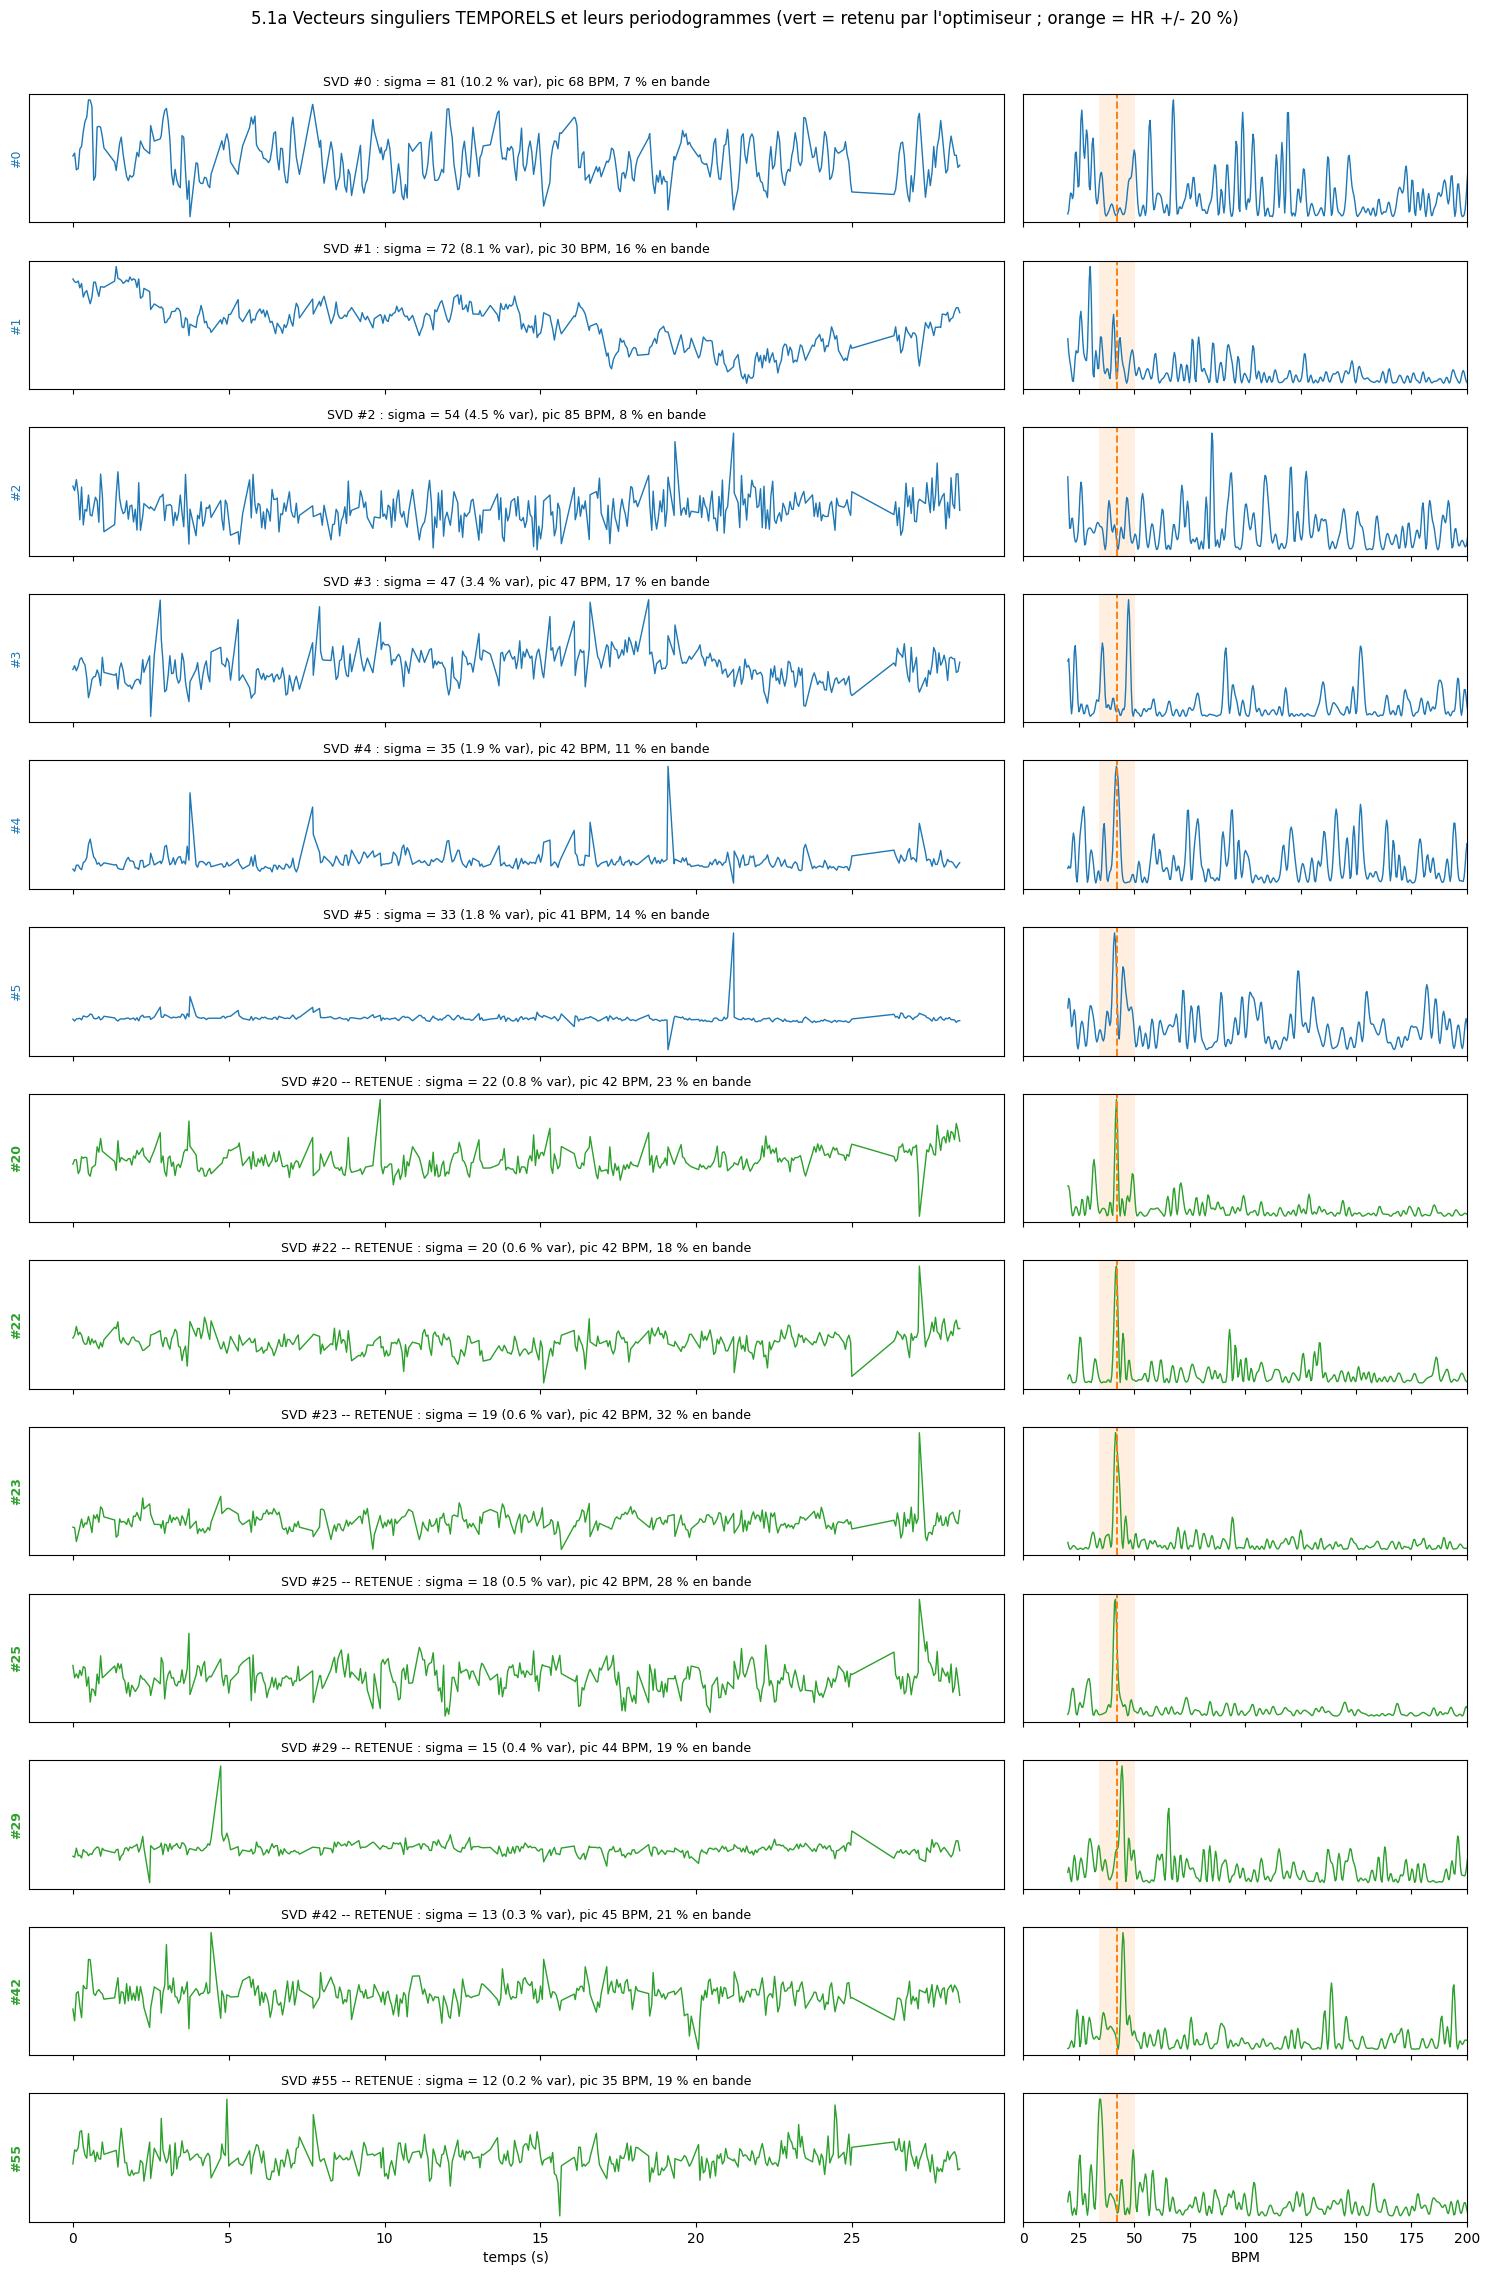

In [17]:
# Coordonnees mesurees le long des modes DMD : Phi^+ X^T, (r, T) complexe.
coords = np.linalg.pinv(dmd.modes) @ X.T
dyn = dmd.amplitudes[:, None] * np.exp(np.outer(dmd.eigs, t))    # modele, (r, T)
pos_modes = [i for i in range(RANK_DMD) if f_bpm[i] > 0]

# Composantes SVD detaillees : celles que l'optimiseur a retenues, plus les
# N_SHOW premieres par valeur singuliere (qui portent la variance mais pas
# forcement le pouls -- c'est le contraste qu'on veut montrer).
show_svd = sorted(set(range(N_SHOW)) | set(int(i) for i in selected))
print(f"composantes SVD detaillees : {show_svd}  "
      f"(retenues : {selected.tolist()})")

fig, axes = plt.subplots(len(show_svd), 2, figsize=(15, 1.75 * len(show_svd)),
                         gridspec_kw={"width_ratios": [2.2, 1.0]})
for r, i in enumerate(show_svd):
    is_sel = i in set(int(j) for j in selected)
    col = "C2" if is_sel else "C0"

    ax = axes[r, 0]
    ax.plot(t, U[:, i] / (np.abs(U[:, i]).max() + 1e-12), lw=1.0, color=col)
    ax.set_yticks([])
    ax.set_ylabel(f"#{i}", fontsize=9, color=col,
                  fontweight="bold" if is_sel else "normal")
    ax.set_title(f"SVD #{i}{' -- RETENUE' if is_sel else ''} : sigma = {S[i]:.0f} "
                 f"({df_svd.loc[i, 'var_%']:.1f} % var), "
                 f"pic {df_svd.loc[i, 'pic_BPM']:.0f} BPM, "
                 f"{df_svd.loc[i, 'en_bande_%']:.0f} % en bande", fontsize=9)
    if r < len(show_svd) - 1:
        ax.set_xticklabels([])

    ax = axes[r, 1]
    ax.plot(bpm_axis, P_svd[:, i] / (P_svd[:, i].max() + 1e-12), lw=1.0, color=col)
    mark_hr(ax, label=False)
    ax.set_xlim(0, 200)
    ax.set_yticks([])
    if r < len(show_svd) - 1:
        ax.set_xticklabels([])
axes[-1, 0].set_xlabel("temps (s)")
axes[-1, 1].set_xlabel("BPM")
fig.suptitle(f"5.1a Vecteurs singuliers TEMPORELS et leurs periodogrammes "
             f"(vert = retenu par l'optimiseur ; orange = HR +/- "
             f"{100 * BAND_FRAC:.0f} %)", fontsize=12, y=0.998)
fig.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

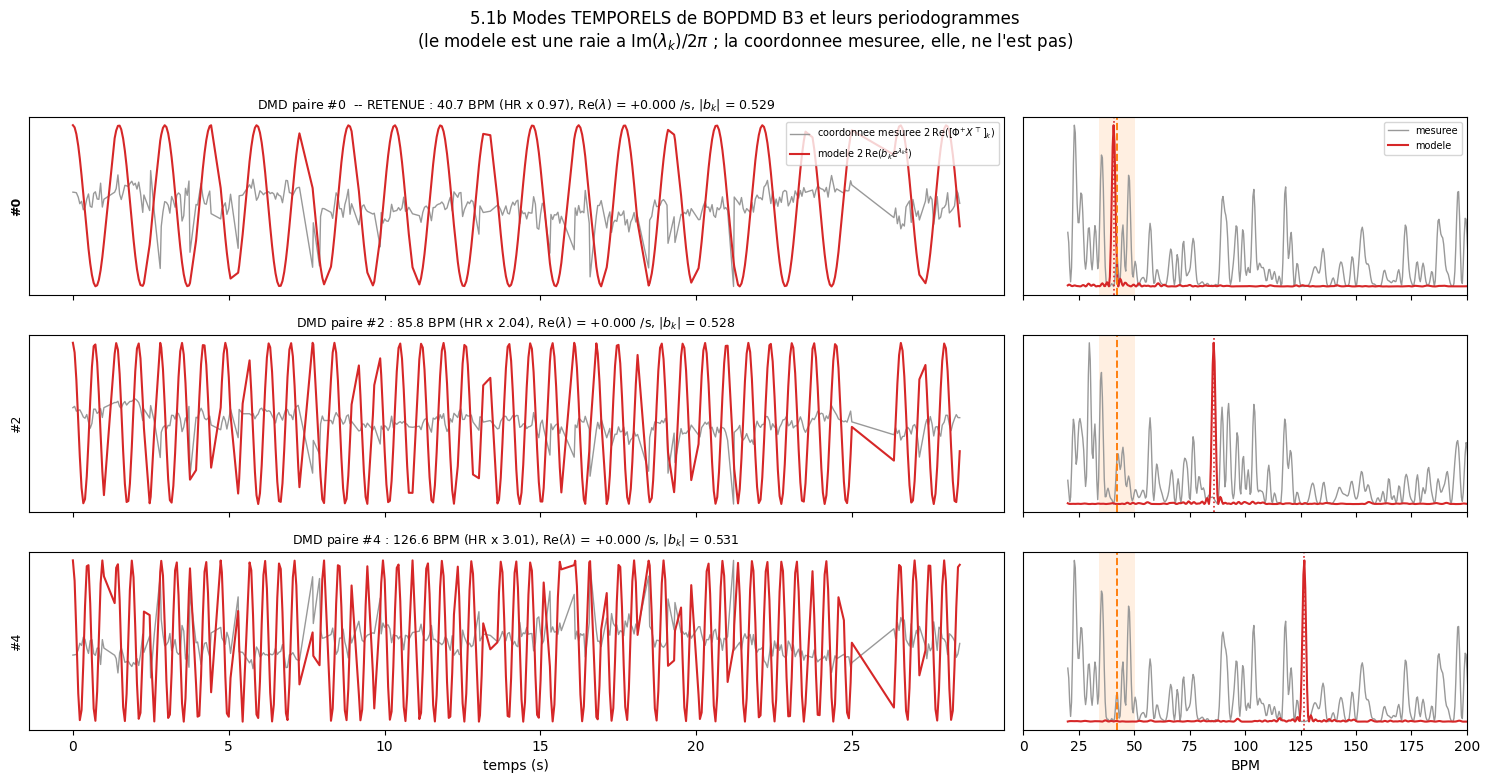

In [18]:
# --- 5.1b Modes DMD : dynamique et periodogramme ------------------------------
fig, axes = plt.subplots(len(pos_modes), 2, figsize=(15, 2.6 * len(pos_modes)),
                         gridspec_kw={"width_ratios": [2.2, 1.0]}, squeeze=False)
for r, i in enumerate(pos_modes):
    ym = 2 * np.real(dyn[i])          # modele
    yc = 2 * np.real(coords[i])       # coordonnee mesuree
    is_ret = i == k_dmd

    ax = axes[r, 0]
    ax.plot(t, yc / (np.abs(yc).max() + 1e-12), lw=1.0, color="0.6",
            label="coordonnee mesuree $2\\,\\mathrm{Re}([\\Phi^{+}X^{\\top}]_k)$")
    ax.plot(t, ym / (np.abs(ym).max() + 1e-12), lw=1.5, color="C3",
            label="modele $2\\,\\mathrm{Re}(b_k e^{\\lambda_k t})$")
    ax.set_yticks([])
    ax.set_ylabel(f"#{i}", fontsize=9, fontweight="bold" if is_ret else "normal")
    ax.set_title(f"DMD paire #{i}{'  -- RETENUE' if is_ret else ''} : "
                 f"{f_bpm[i]:.1f} BPM (HR x {f_bpm[i] / hr:.2f}), "
                 f"Re$(\\lambda)$ = {V_DMD['growth'][i]:+.3f} /s, "
                 f"$|b_k|$ = {abs(dmd.amplitudes[i]):.3g}", fontsize=9)
    if r == 0:
        ax.legend(fontsize=7, loc="upper right")
    if r < len(pos_modes) - 1:
        ax.set_xticklabels([])

    ax = axes[r, 1]
    Pc = spectrum(yc)
    Pm = spectrum(ym)
    ax.plot(bpm_axis, Pc / (Pc.max() + 1e-12), lw=1.0, color="0.6",
            label="mesuree")
    ax.plot(bpm_axis, Pm / (Pm.max() + 1e-12), lw=1.5, color="C3", label="modele")
    ax.axvline(f_bpm[i], color="C3", ls=":", lw=1.2)
    mark_hr(ax, label=False)
    ax.set_xlim(0, 200)
    ax.set_yticks([])
    if r == 0:
        ax.legend(fontsize=7)
    if r < len(pos_modes) - 1:
        ax.set_xticklabels([])
axes[-1, 0].set_xlabel("temps (s)")
axes[-1, 1].set_xlabel("BPM")
fig.suptitle(f"5.1b Modes TEMPORELS de BOPDMD {RETAINED} et leurs periodogrammes\n"
             "(le modele est une raie a $\\mathrm{Im}(\\lambda_k)/2\\pi$ ; la "
             "coordonnee mesuree, elle, ne l'est pas)", fontsize=12, y=0.998)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

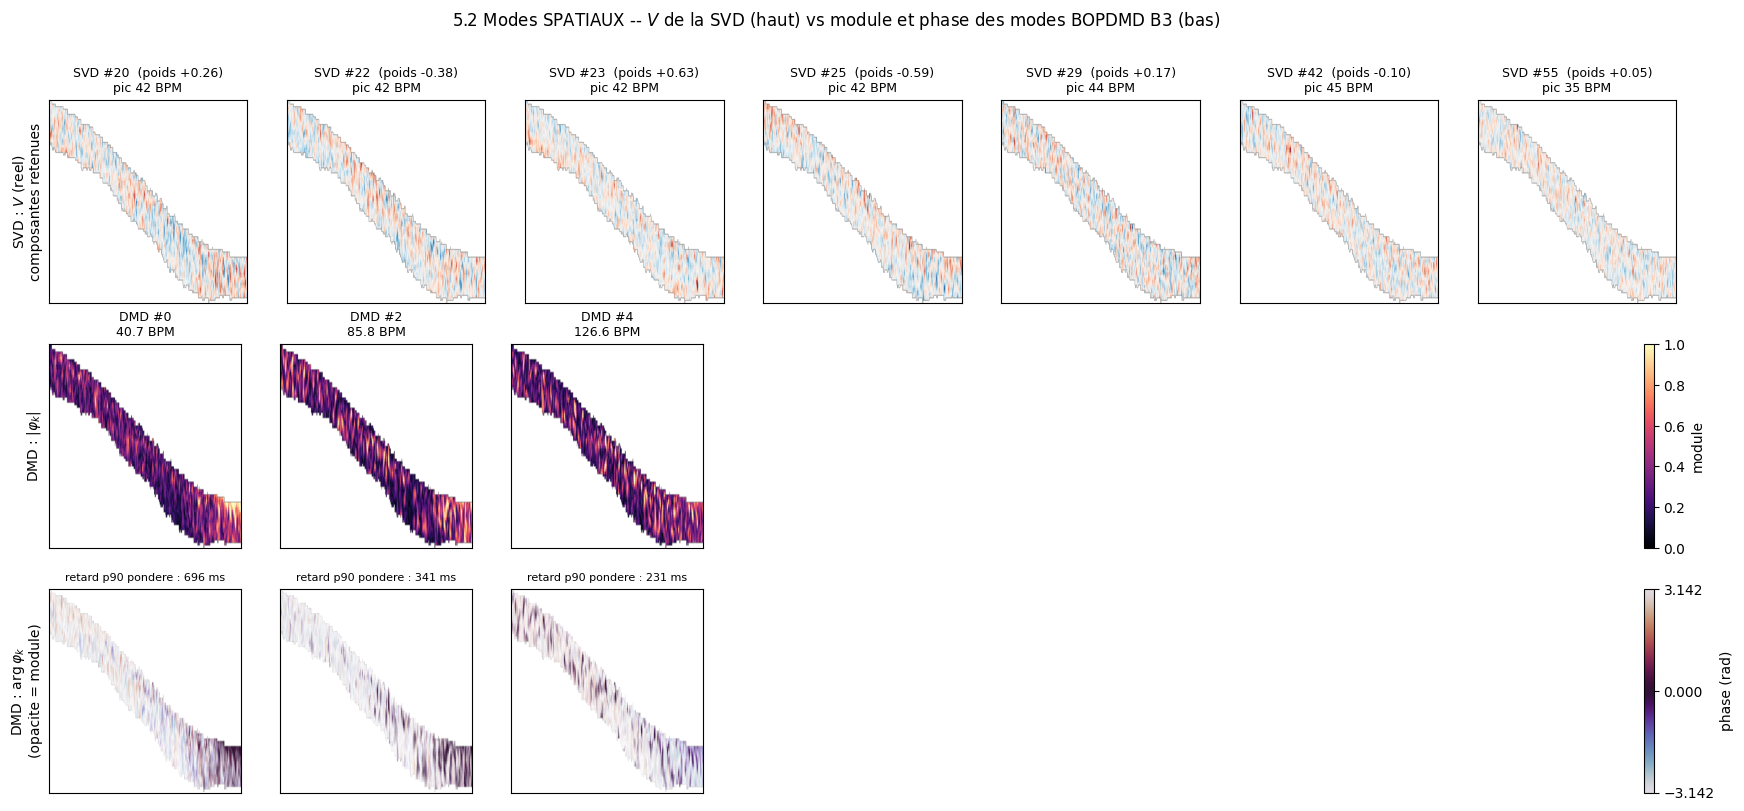

In [19]:
# --- 5.2 Modes SPATIAUX -------------------------------------------------------
# Cote SVD on montre les composantes RETENUES par l'optimiseur : ce sont elles
# qui construisent le pouls, montrer les 100 n'aurait aucun sens.
show_spatial = [int(i) for i in selected][:8]
n_cols = max(len(show_spatial), len(pos_modes))
fig, axes = plt.subplots(3, n_cols, figsize=(3.0 * n_cols, 9.0),
                         sharex=True, sharey=True, squeeze=False)

for c, i in enumerate(show_spatial):
    ax = axes[0, c]
    v = V[:, i] / (np.abs(V[:, i]).max() + 1e-12)
    ax.imshow(as_image(v), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    w_i = weights[list(selected).index(i)]
    ax.set_title(f"SVD #{i}  (poids {w_i:+.2f})\npic "
                 f"{df_svd.loc[i, 'pic_BPM']:.0f} BPM", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
for c in range(len(show_spatial), n_cols):
    axes[0, c].axis("off")
axes[0, 0].set_ylabel("SVD : $V$ (reel)\ncomposantes retenues", fontsize=10)

im_a = im_p = None
for r, i in enumerate(pos_modes):
    phi = dmd.modes[:, i]
    amp = np.abs(phi)
    # Echelle au 99e centile et non au max : quelques pixels tres brillants
    # ecraseraient sinon tout le reste de la carte.
    vmax_a = np.percentile(amp, 99)
    ax = axes[1, r]
    im_a = ax.imshow(as_image(np.clip(amp / (vmax_a + 1e-12), 0, 1)), cmap="magma",
                     vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"DMD #{i}\n{f_bpm[i]:.1f} BPM", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

    # Phase RELATIVE au pixel de plus grand module : le zero de phase d'un mode
    # DMD est arbitraire, seuls les ecarts de phase entre pixels ont un sens.
    rel = np.angle(phi * np.exp(-1j * np.angle(phi[np.argmax(amp)])))
    # La phase d'un pixel de module ~0 n'est que du bruit : on l'estompe en
    # proportion du module plutot que de laisser le fond parasiter la lecture.
    alpha = as_image(np.clip(amp / (vmax_a + 1e-12), 0, 1))
    ax = axes[2, r]
    im_p = ax.imshow(as_image(rel), cmap="twilight", vmin=-np.pi, vmax=np.pi,
                     aspect="auto", alpha=np.nan_to_num(alpha, nan=0.0))
    # Retard implique par le dephasage, pondere par le module (les pixels muets
    # ne doivent pas peser dans la statistique).
    w = amp / (amp.sum() + 1e-12)
    lag_ms = np.abs(rel) / (2 * np.pi * f_bpm[i] / 60.0) * 1e3
    order = np.argsort(lag_ms)
    lag_p90 = lag_ms[order][np.searchsorted(np.cumsum(w[order]), 0.9)]
    ax.set_title(f"retard p90 pondere : {lag_p90:.0f} ms", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
for r in range(len(pos_modes), n_cols):
    axes[1, r].axis("off")
    axes[2, r].axis("off")
axes[1, 0].set_ylabel(r"DMD : $|\varphi_k|$", fontsize=10)
axes[2, 0].set_ylabel(r"DMD : $\arg \varphi_k$" "\n(opacite = module)", fontsize=10)
fig.colorbar(im_a, ax=axes[1, :].tolist(), fraction=0.02, pad=0.01, label="module")
fig.colorbar(im_p, ax=axes[2, :].tolist(), fraction=0.02, pad=0.01,
             label="phase (rad)", ticks=[-np.pi, 0, np.pi])
fig.suptitle(f"5.2 Modes SPATIAUX -- $V$ de la SVD (haut) vs module et phase des "
             f"modes BOPDMD {RETAINED} (bas)", fontsize=12)
plt.show()

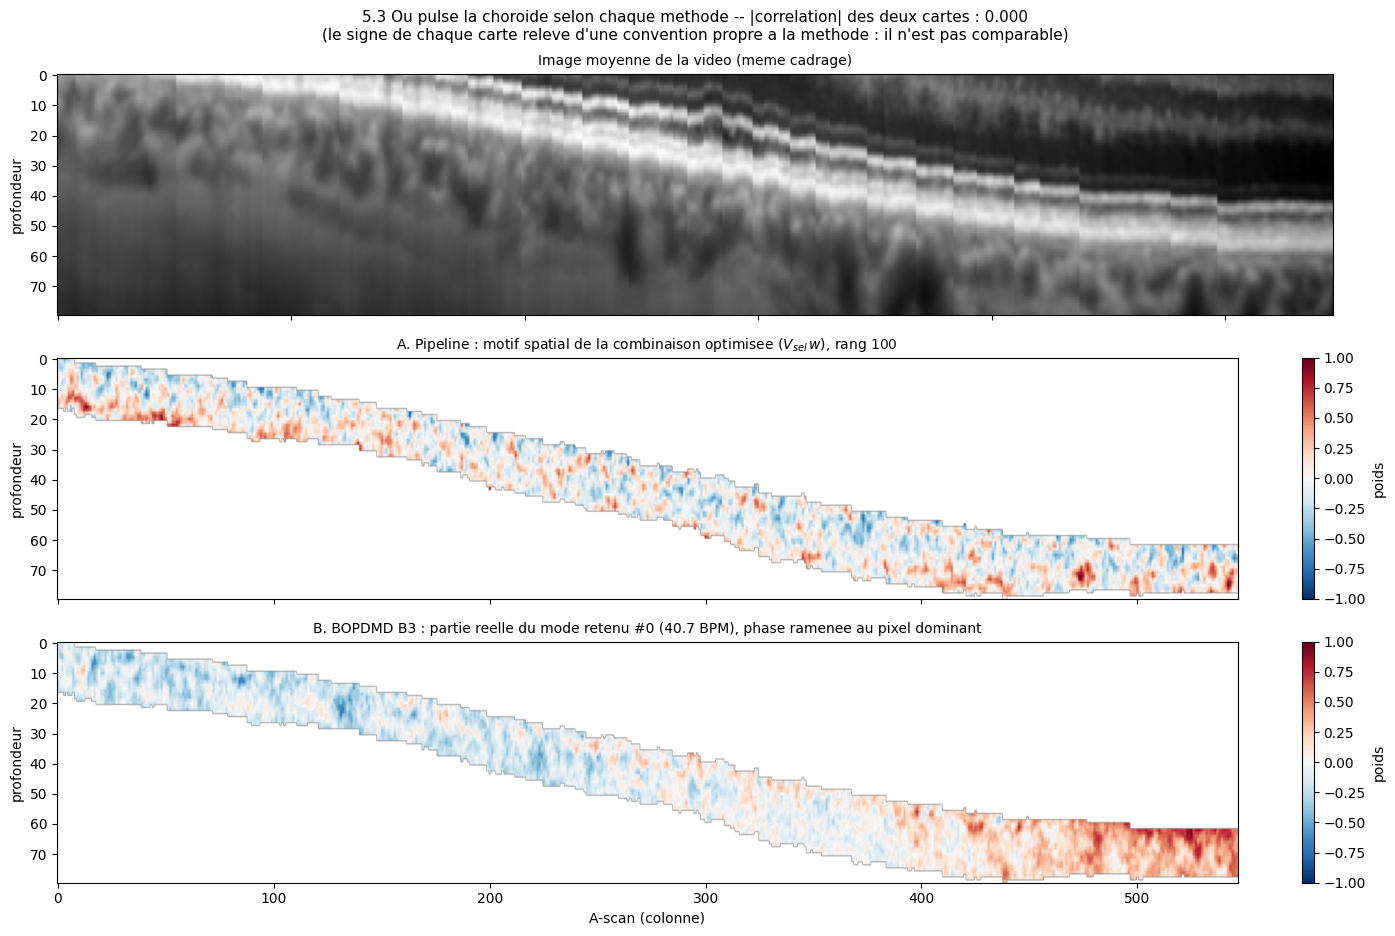

In [20]:
# --- 5.3 Motif spatial du POULS retenu, de part et d'autre -------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 9.5), sharex=True, sharey=True)

axes[0].imshow(mean_frame[_BOX], cmap="gray", aspect="auto")
axes[0].set_title("Image moyenne de la video (meme cadrage)", fontsize=10)
axes[0].set_ylabel("profondeur")

p = np.asarray(pattern_svd, dtype=float)
p = p / (np.abs(p).max() + 1e-12)
im = axes[1].imshow(as_image(p), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[1], fraction=0.025, label="poids")
axes[1].set_title(f"A. Pipeline : motif spatial de la combinaison optimisee "
                  f"($V_{{sel}}\\,w$), rang {RANK_SVD}", fontsize=10)
axes[1].set_ylabel("profondeur")

phi = dmd.modes[:, k_dmd]
amp = np.abs(phi)
signed = np.real(phi * np.exp(-1j * np.angle(phi[np.argmax(amp)])))
signed = signed / (np.abs(signed).max() + 1e-12)
im = axes[2].imshow(as_image(signed), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[2], fraction=0.025, label="poids")
axes[2].set_title(f"B. BOPDMD {RETAINED} : partie reelle du mode retenu #{k_dmd} "
                  f"({hr_dmd:.1f} BPM), phase ramenee au pixel dominant", fontsize=10)
axes[2].set_xlabel("A-scan (colonne)")
axes[2].set_ylabel("profondeur")

# Chaque carte porte sa propre convention de signe -- le pipeline la fixe sur
# `sign_ref`, la DMD sur le pixel de plus grand module -- et ces deux
# conventions sont independantes. Seul |correlation| est interpretable.
corr_pattern = np.corrcoef(p, signed)[0, 1]
fig.suptitle(f"5.3 Ou pulse la choroide selon chaque methode -- |correlation| des "
             f"deux cartes : {abs(corr_pattern):.3f}\n(le signe de chaque carte "
             f"releve d'une convention propre a la methode : il n'est pas "
             f"comparable)", fontsize=11)
fig.tight_layout()
plt.show()

## 6. Le pouls retenu

Trois traces, toutes reduites (ecart-type 1) :

- **A. pipeline rang 100** -- `y_svd`, la combinaison optimisee ;
- **B. DMD modele** -- $2\,\mathrm{Re}(b_k e^{\lambda_k t})$, la sinusoide que le
  modele affirme ;
- **B'. DMD projete** -- $2\,\mathrm{Re}([\Phi^{+}X^{\top}]_k)$, les donnees le long
  du mode retenu.

C'est **B'** qu'il faut comparer a **A** : meme statut, une trace extraite des
donnees. **B** est deja un modele.

Deux pieges de lecture, a garder en tete devant le tableau de la section 8 :

- **La colonne `en_bande_%` est trompeuse pour B.** Une sinusoide pure a
  40,7 BPM met par construction toute sa puissance dans la bande 33,6-50,4 BPM :
  son score eleve mesure l'hypothese du modele, pas la qualite de l'ajustement.
- **B' recupere tout ce que le rang 6 n'explique pas.** $\Phi^{+}$ est la
  pseudo-inverse d'une base **non orthogonale** de 6 modes dans un espace de
  401 instants : la coordonnee du mode retenu absorbe une partie du residu
  (harmonique 2, derive basse frequence). C'est pour cela que son pic
  Lomb-Scargle ne tombe pas forcement sur la frequence du mode dont elle est la
  coordonnee. Ce n'est pas un bug : c'est l'ecart entre le modele DMD et les
  donnees, rendu visible. Sa correlation avec A et son decalage a l'echelle du
  cycle (calcules plus bas) restent, eux, informatifs.

  signe [DMD modele] : phaseur a f0 = +4.58 (corr large bande +0.068)
  signe [DMD projete] : phaseur a f0 = -489 (corr large bande -0.222)   -> retourne


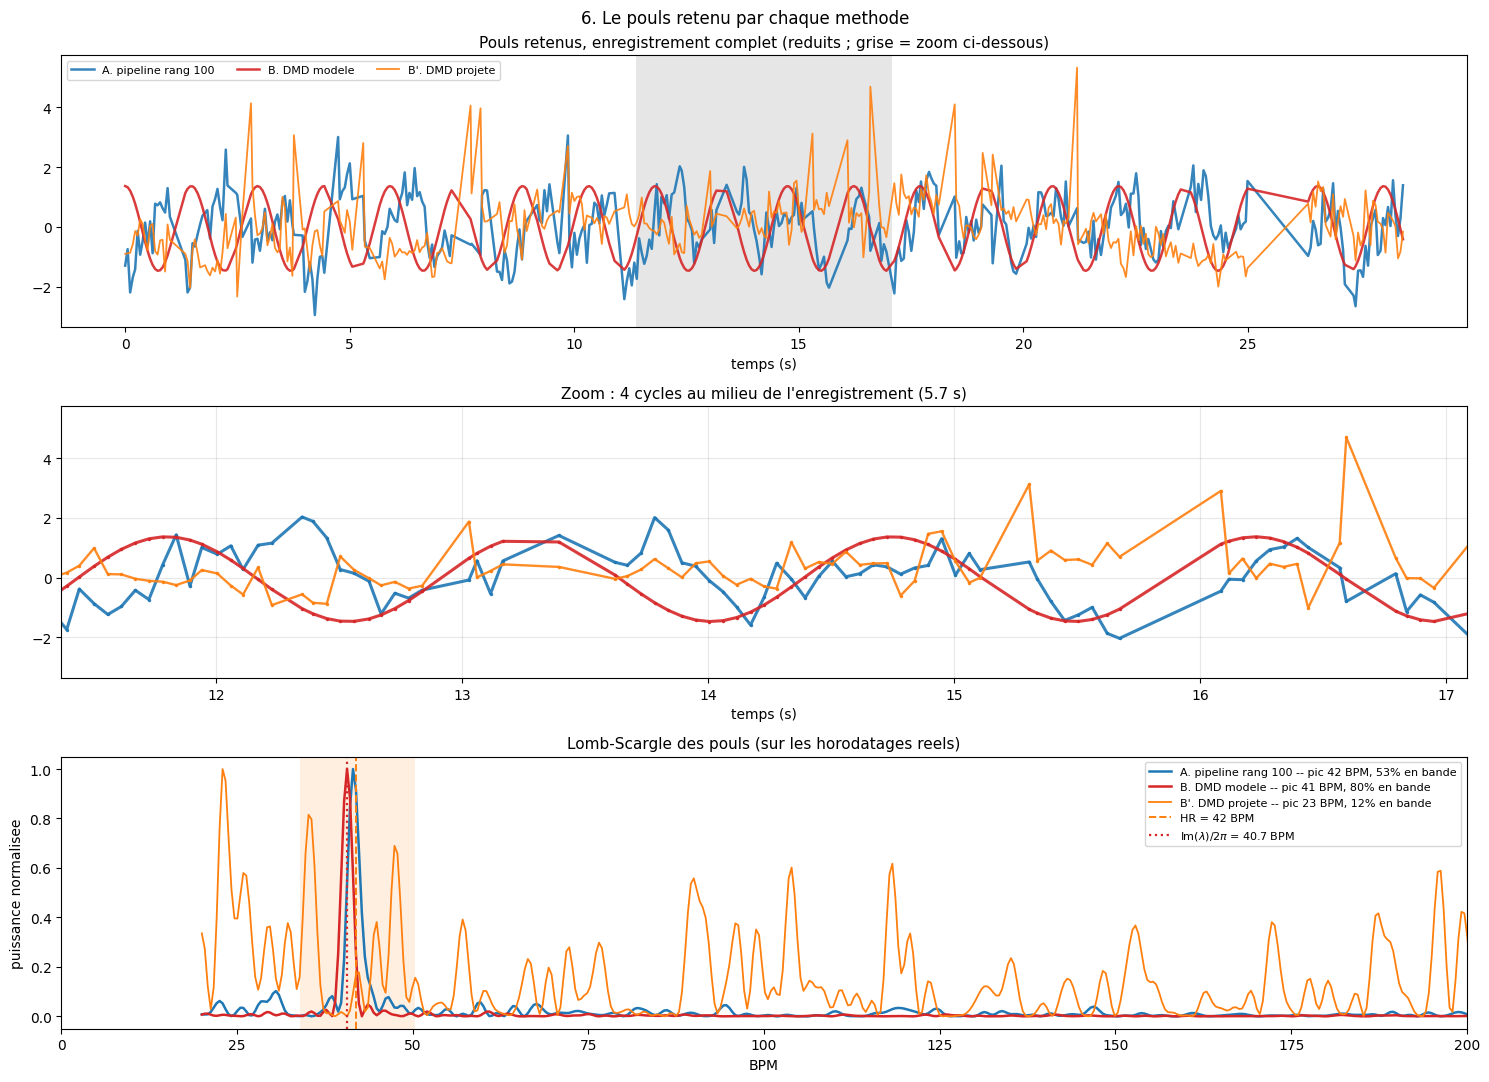

In [21]:
# --- Les pouls DMD ------------------------------------------------------------
y_dmd_model = 2 * np.real(dmd.amplitudes[k_dmd] * np.exp(dmd.eigs[k_dmd] * t))
y_dmd_proj = 2 * np.real(coords[k_dmd])
y_dmd_model, _ = fix_sign(y_dmd_model, "DMD modele")
y_dmd_proj, _ = fix_sign(y_dmd_proj, "DMD projete")

PULSES = {
    f"A. pipeline rang {RANK_SVD}": (y_svd, "C0", 1.8),
    "B. DMD modele": (y_dmd_model, "C3", 1.8),
    "B'. DMD projete": (y_dmd_proj, "C1", 1.3),
}

mid = 0.5 * (t[0] + t[-1])
half = 2.0 * 60.0 / hr          # +/- 2 cycles cardiaques

fig, axes = plt.subplots(3, 1, figsize=(15, 11))

for name, (y, c, lw) in PULSES.items():
    axes[0].plot(t, z(y), lw=lw, color=c, alpha=0.9, label=name)
axes[0].axvspan(mid - half, mid + half, color="0.9", lw=0, zorder=0)
axes[0].set_title("Pouls retenus, enregistrement complet (reduits ; grise = zoom "
                  "ci-dessous)", fontsize=11)
axes[0].set_xlabel("temps (s)")
axes[0].legend(fontsize=8, ncol=4)

for name, (y, c, lw) in PULSES.items():
    axes[1].plot(t, z(y), lw=lw + 0.4, color=c, alpha=0.9, marker=".", ms=3)
axes[1].set_xlim(mid - half, mid + half)
axes[1].set_title(f"Zoom : 4 cycles au milieu de l'enregistrement "
                  f"({2 * half:.1f} s)", fontsize=11)
axes[1].set_xlabel("temps (s)")
axes[1].grid(alpha=0.3)

for name, (y, c, lw) in PULSES.items():
    P = spectrum(y)
    fr, pk = band_score(y)
    axes[2].plot(bpm_axis, P / (P.max() + 1e-12), lw=lw, color=c,
                 label=f"{name} -- pic {pk:.0f} BPM, {fr:.0%} en bande")
mark_hr(axes[2])
axes[2].axvline(hr_dmd, color="C3", ls=":", lw=1.6,
                label=f"$\\mathrm{{Im}}(\\lambda)/2\\pi$ = {hr_dmd:.1f} BPM")
axes[2].set_xlim(0, 200)
axes[2].set_xlabel("BPM")
axes[2].set_ylabel("puissance normalisee")
axes[2].set_title("Lomb-Scargle des pouls (sur les horodatages reels)", fontsize=11)
axes[2].legend(fontsize=8)
fig.suptitle("6. Le pouls retenu par chaque methode", fontsize=12)
fig.tight_layout()
plt.show()

In [22]:
# --- Correlations croisees entre pouls ---------------------------------------
names = list(PULSES)
M = np.array([[np.corrcoef(z(PULSES[a][0]), z(PULSES[b][0]))[0, 1] for b in names]
              for a in names])
print("Correlation de Pearson entre les pouls (sur `t`, sans decalage) :")
display(pd.DataFrame(M, index=names, columns=names).round(3))


def best_lag(a, b):
    """Decalage du maximum de |correlation croisee|, borne a +/- un demi-cycle.
    Un lag > 0 signifie que `b` est EN RETARD sur `a`."""
    xa, xb = z(a), z(b)
    xc = np.correlate(xa, xb, mode="full") / len(xa)
    lags = np.arange(-len(xa) + 1, len(xa)) * np.median(np.diff(t))
    keep = np.abs(lags) <= 0.5 * 60.0 / hr
    j = int(np.argmax(np.abs(xc[keep])))
    return lags[keep][j], xc[keep][j]


for label, y in [("B' (DMD projete)", y_dmd_proj), ("B  (DMD modele) ", y_dmd_model)]:
    lag, val = best_lag(y_svd, y)
    print(f"A (pipeline rang {RANK_SVD}) vs {label} : decalage {lag * 1e3:+7.0f} ms "
          f"({lag * f0 * 360:+6.0f} deg), |xc| = {abs(val):.3f}")

Correlation de Pearson entre les pouls (sur `t`, sans decalage) :


,A. pipeline rang 100,B. DMD modele,B'. DMD projete
A. pipeline rang 100,1.000,0.084,-0.000
B. DMD modele,0.084,1.000,-0.003
B'. DMD projete,-0.000,-0.003,1.000


A (pipeline rang 100) vs B' (DMD projete) : decalage    +392 ms (   +99 deg), |xc| = 0.137
A (pipeline rang 100) vs B  (DMD modele)  : decalage    +224 ms (   +56 deg), |xc| = 0.433


In [23]:
# La reference de signe est faible en large bande : c'est pour cela que la
# polarite est tranchee sur le phaseur a f0 (section 3). On l'affiche pour que
# le lecteur sache a quel point la lecture "en phase / en opposition" est
# fragile ici.
print(f"reference de signe : |corr| large bande va de "
      f"{min(abs(np.corrcoef(z(y), sign_ref)[0, 1]) for y, _, _ in PULSES.values()):.3f} a "
      f"{max(abs(np.corrcoef(z(y), sign_ref)[0, 1]) for y, _, _ in PULSES.values()):.3f}"
      "\n  -> polarite mal determinee en large bande ; c'est le phaseur a f0 "
      "qui l'a fixee.")

reference de signe : |corr| large bande va de 0.008 a 0.222
  -> polarite mal determinee en large bande ; c'est le phaseur a f0 qui l'a fixee.


## 7. Phase et rythme cardiaque instantane

**Pipeline** : passe-bande cardiaque (exactement celui de
`AbstractUniformTraceSource.filtered_signal` -- meme `spatio_temporal_filter`,
memes coupures normalisees), puis signal analytique de Hilbert ;
$f(t) = \dot\varphi / 2\pi$, filtre median sur un cycle.

**DMD** : les deux lectures convenues.

1. $\mathrm{Im}(\lambda_k) / 2\pi$ -- **constante par construction**. Un
   ajustement BOPDMD unique ne peut pas produire de variabilite
   battement-a-battement : la frequence est un parametre du modele, pas une
   fonction du temps. La phase associee, $\arg(b_k e^{\lambda_k t})$, est
   exactement lineaire.
2. Le meme traitement Hilbert applique au pouls **projete** B', pour une
   comparaison a traitement identique.

> Le FIR fait ici ~169 taps (~9,5 s) pour un enregistrement de ~28 s : les bords
> portent un transitoire enorme. Les zones grisees de la figure 7.3 sont
> exclues de toute statistique.

In [24]:
# --- Passe-bande identique a celui de la chaine de reconstruction ------------
_NYQ = 0.5 * aligner.fs
_LO_BPM, _HI_BPM = band.effective_bpm_range
_LOW = (_LO_BPM / 60.0) / _NYQ
_HIGH = min((_HI_BPM / 60.0) / _NYQ, 0.99)
_ntaps = min(max(int(round(4.0 * aligner.fs / _LOW)), 31),
             max(3, (u_time.size // 3) | 1))
_ntaps += (_ntaps + 1) % 2
print(f"passe-bande : {_LO_BPM:.1f} - {_HI_BPM:.1f} BPM, fs = {aligner.fs:.2f} Hz, "
      f"coupures normalisees {_LOW:.4f} / {_HIGH:.4f}")
print(f"FIR         : ~{_ntaps} taps = {_ntaps / aligner.fs:.1f} s, sur "
      f"{u_time[-1] - u_time[0]:.1f} s d'enregistrement")

EDGE_FRAC = 0.2                         # bords exclus des statistiques
_m = int(EDGE_FRAC * u_time.size)
core = np.zeros(u_time.size, dtype=bool)
core[_m:u_time.size - _m] = True


def bandpass_pulse(y):
    """Passe-bande cardiaque d'une trace vivant sur `t`, renvoyee sur `u_time`.

    Le FIR suppose un echantillonnage uniforme : on interpole d'abord sur la
    grille de l'aligner -- exactement ce que fait `filtered_signal`, qui filtre
    `interpolated_signal` et non le signal brut.
    """
    yu = np.interp(u_time, t, np.asarray(y, dtype=float))
    return spatio_temporal_filter(yu[:, None], 0.0, _LOW, _HIGH,
                                  aligner.fs, None)[:, 0]


def phase_and_rate(y):
    """(pouls filtre, phase repliee, BPM instantane) par Hilbert."""
    yf = bandpass_pulse(y)
    analytic = hilbert(yf - yf.mean())
    ph = np.unwrap(np.angle(analytic))
    f_inst = np.gradient(ph, u_time) / (2 * np.pi)
    win = int(round(aligner.fs / f0)) | 1            # median sur un cycle
    if 1 < win < f_inst.size:
        f_inst = medfilt(f_inst, win)
    return yf, np.mod(ph, 2 * np.pi), f_inst * 60.0


yf_svd, ph_svd, bpm_svd = phase_and_rate(y_svd)
yf_dmd, ph_dmd, bpm_dmd = phase_and_rate(y_dmd_proj)

# Phase ANALYTIQUE du mode DMD : arg(b_k e^{lambda_k t}), exactement lineaire.
ph_dmd_exact = np.mod(np.angle(dmd.amplitudes[k_dmd])
                      + dmd.eigs[k_dmd].imag * u_time, 2 * np.pi)

print()
for nm, b in [(f"pipeline rang {RANK_SVD}", bpm_svd),
              ("DMD projete (Hilbert)", bpm_dmd)]:
    bc = b[core]
    print(f"{nm:<26s} HR mediane {np.median(bc):6.1f} BPM   "
          f"IQR {np.percentile(bc, 25):5.1f} - {np.percentile(bc, 75):5.1f}   "
          f"etendue {bc.min():5.1f} - {bc.max():5.1f}")
print(f"{'DMD Im(lambda)/2pi':<26s} HR {hr_dmd:10.2f} BPM   "
      f"(constante par construction)")
print(f"{'visit_data.csv':<26s} HR {hr:10.1f} BPM")

passe-bande : 33.6 - 50.4 BPM, fs = 17.86 Hz, coupures normalisees 0.0627 / 0.0941
FIR         : ~169 taps = 9.5 s, sur 28.4 s d'enregistrement

pipeline rang 100          HR mediane   41.8 BPM   IQR  41.0 -  42.0   etendue  39.6 -  42.2
DMD projete (Hilbert)      HR mediane   41.3 BPM   IQR  38.9 -  43.0   etendue  32.1 -  51.3
DMD Im(lambda)/2pi         HR      40.68 BPM   (constante par construction)
visit_data.csv             HR       42.0 BPM


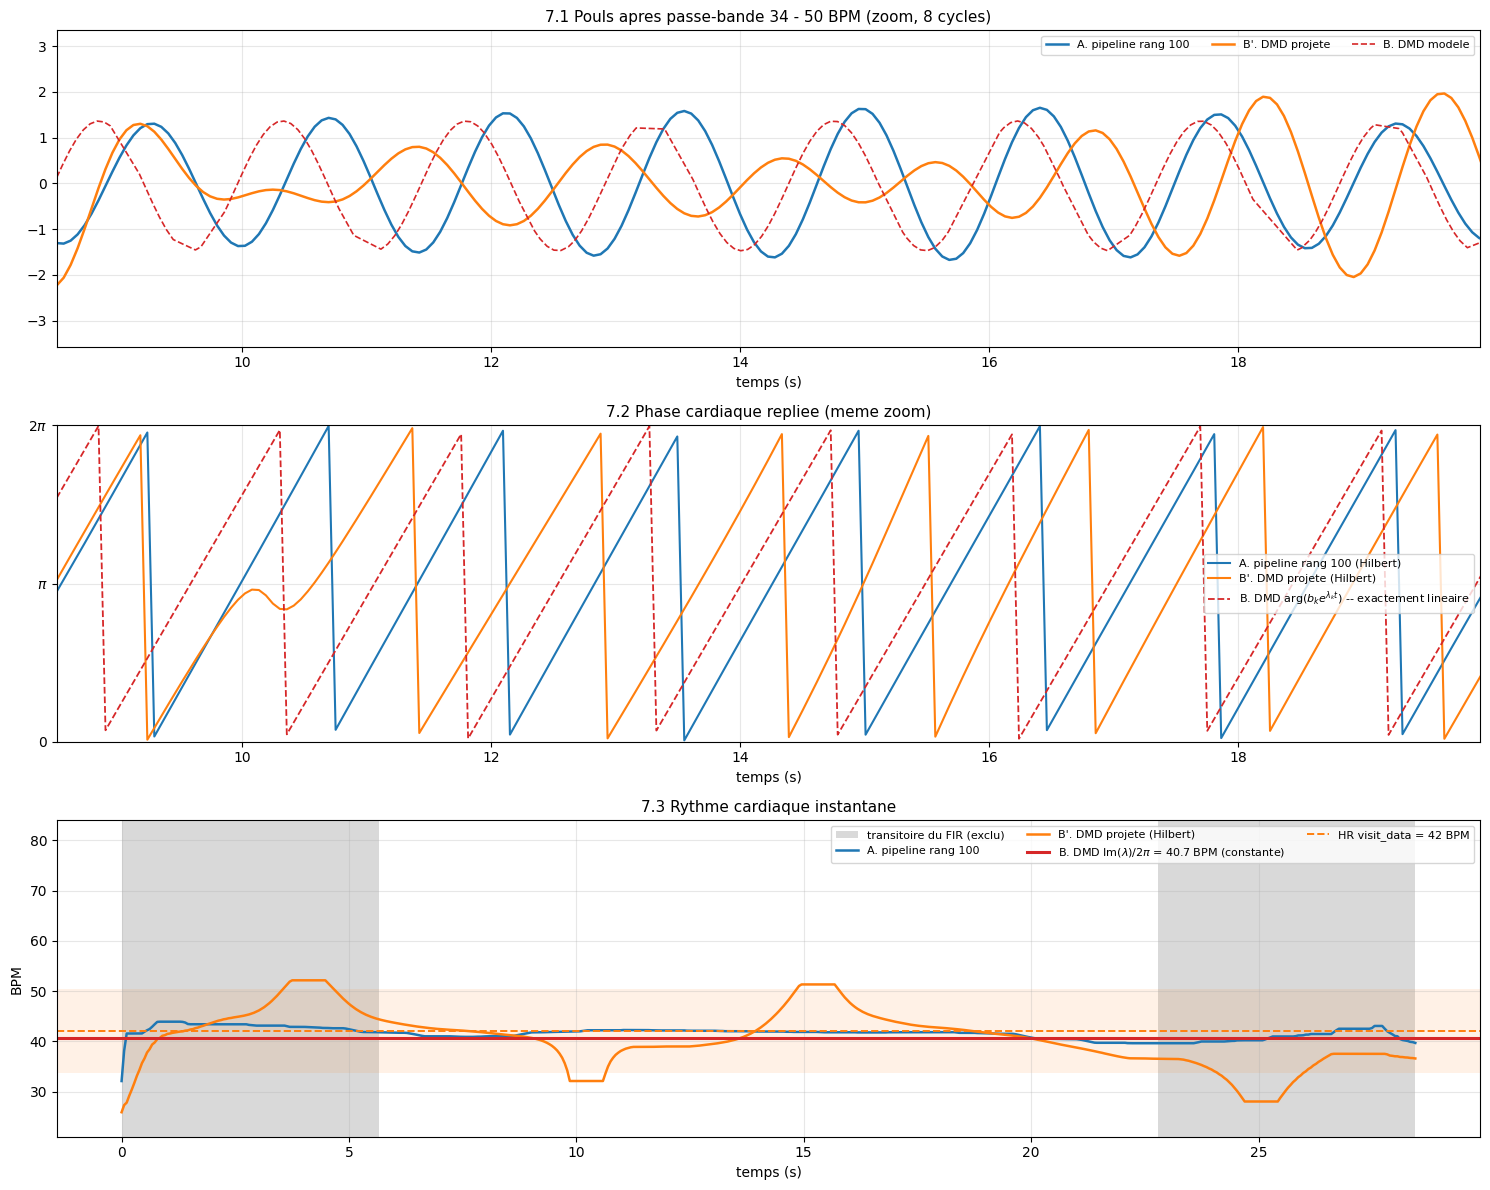

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# -- 7.1 pouls passe-bande, zoom milieu ---------------------------------------
ax = axes[0]
ax.plot(u_time, z(yf_svd), lw=1.8, color="C0", label=f"A. pipeline rang {RANK_SVD}")
ax.plot(u_time, z(yf_dmd), lw=1.8, color="C1", label="B'. DMD projete")
ax.plot(t, z(y_dmd_model), lw=1.2, color="C3", ls="--", label="B. DMD modele")
ax.set_xlim(mid - 2 * half, mid + 2 * half)
ax.set_title(f"7.1 Pouls apres passe-bande {_LO_BPM:.0f} - {_HI_BPM:.0f} BPM "
             "(zoom, 8 cycles)", fontsize=11)
ax.set_xlabel("temps (s)")
ax.legend(fontsize=8, ncol=4)
ax.grid(alpha=0.3)

# -- 7.2 phase repliee ---------------------------------------------------------
ax = axes[1]
ax.plot(u_time, ph_svd, lw=1.5, color="C0", label=f"A. pipeline rang {RANK_SVD} (Hilbert)")
ax.plot(u_time, ph_dmd, lw=1.5, color="C1", label="B'. DMD projete (Hilbert)")
ax.plot(u_time, ph_dmd_exact, lw=1.3, color="C3", ls="--",
        label=r"B. DMD $\arg(b_k e^{\lambda_k t})$ -- exactement lineaire")
ax.set_xlim(mid - 2 * half, mid + 2 * half)
ax.set_ylim(0, 2 * np.pi)
ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
ax.set_title("7.2 Phase cardiaque repliee (meme zoom)", fontsize=11)
ax.set_xlabel("temps (s)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# -- 7.3 rythme cardiaque instantane ------------------------------------------
ax = axes[2]
ax.axvspan(u_time[0], u_time[_m], color="0.85", lw=0, zorder=0)
ax.axvspan(u_time[-_m - 1], u_time[-1], color="0.85", lw=0, zorder=0,
           label="transitoire du FIR (exclu)")
ax.plot(u_time, bpm_svd, lw=1.8, color="C0", label=f"A. pipeline rang {RANK_SVD}")
ax.plot(u_time, bpm_dmd, lw=1.8, color="C1", label="B'. DMD projete (Hilbert)")
ax.axhline(hr_dmd, color="C3", lw=2.2,
           label=f"B. DMD $\\mathrm{{Im}}(\\lambda)/2\\pi$ = {hr_dmd:.1f} BPM "
                 f"(constante)")
ax.axhline(hr, color="C1", lw=1.4, ls="--", label=f"HR visit_data = {hr:.0f} BPM")
ax.axhspan(*band.effective_bpm_range, color="C1", alpha=0.10, lw=0)
ax.set_ylim(0.5 * hr, 2.0 * hr)
ax.set_xlabel("temps (s)")
ax.set_ylabel("BPM")
ax.set_title("7.3 Rythme cardiaque instantane", fontsize=11)
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Bilan chiffre

In [26]:
def summarize(name, y, bpm_track=None, extra=None):
    fr, pk = band_score(y)
    row = {"methode": name, "pic_LS_BPM": pk, "en_bande_%": 100 * fr,
           "corr_avec_ref_signe": np.corrcoef(np.asarray(y, dtype=float),
                                              sign_ref)[0, 1]}
    if bpm_track is not None:
        bc = bpm_track[core]
        row["HR_med_BPM"] = np.median(bc)
        row["HR_IQR_BPM"] = np.percentile(bc, 75) - np.percentile(bc, 25)
    row.update(extra or {})
    return row


summary = pd.DataFrame([
    summarize(f"A. pipeline SVD rang {RANK_SVD}", y_svd, bpm_svd,
              {"cout_s": t_svd + t_per + diag_svd["elapsed"],
               "min_conc_requis": diag_svd["min_conc"],
               "n_candidates": selected.size}),
    summarize(f"B. BOPDMD {RETAINED} modele", y_dmd_model, None,
              {"cout_s": V_DMD["elapsed"], "HR_med_BPM": hr_dmd, "HR_IQR_BPM": 0.0}),
    summarize(f"B'. BOPDMD {RETAINED} projete", y_dmd_proj, bpm_dmd,
              {"cout_s": V_DMD["elapsed"]}),
]).set_index("methode")
display(summary.round(3))

f_pos = np.sort(f_bpm[f_bpm > 0])
print(f"\nHR de reference (visit_data.csv) : {hr:.0f} BPM")
print(f"HR portee par la valeur propre   : {hr_dmd:.2f} BPM   "
      f"(ecart {hr_dmd - hr:+.2f} BPM, {100 * (hr_dmd - hr) / hr:+.1f} %)")
print(f"Harmoniques DMD retenues         : {np.round(f_pos, 1).tolist()} BPM "
      f"= HR x {np.round(f_pos / hr, 2).tolist()}")
print(f"Correlation A vs B' (pouls)      : "
      f"{np.corrcoef(z(y_svd), z(y_dmd_proj))[0, 1]:+.3f}")

,pic_LS_BPM,en_bande_%,corr_avec_ref_signe,HR_med_BPM,HR_IQR_BPM,cout_s,min_conc_requis,n_candidates
methode,,,,,,,,
A. pipeline SVD rang 100,41.507,53.326,0.008,41.793,0.949,2.772,0.15,7.0
B. BOPDMD B3 modele,40.663,79.873,0.068,40.675,0.000,1.058,NaN,NaN
B'. BOPDMD B3 projete,22.952,12.451,0.222,41.266,4.086,1.058,NaN,NaN



HR de reference (visit_data.csv) : 42 BPM
HR portee par la valeur propre   : 40.68 BPM   (ecart -1.32 BPM, -3.2 %)
Harmoniques DMD retenues         : [40.70000076293945, 85.80000305175781, 126.5999984741211] BPM = HR x [0.9700000286102295, 2.0399999618530273, 3.009999990463257]
Correlation A vs B' (pouls)      : -0.000


## 9. Ce qu'on retient, et ce qui reste a faire

### Sur BOPDMD

1. **L'initialisation est le parametre critique, pas le rang.** A
   `svd_rank=6`, `init_alpha` par defaut converge sur la derive basse frequence
   (~6, ~3, ~11 BPM) et rate le pouls d'un ordre de grandeur. Seedee sur les
   harmoniques de la HR, la meme configuration verrouille le fondamental **et**
   ses harmoniques 2 et 3 (HR x 0,97 / 2,04 / 3,01) -- une decomposition
   harmonique du pouls que la SVD ne donne pas gratuitement. Toute utilisation
   en batch devra donc passer un `init_alpha`, c'est-a-dire **disposer d'une HR
   a priori**. Le pipeline actuel l'exige deja (`override_bpm`), mais avec une
   tolerance bien plus large : il cherche un pic dans une bande, la DMD part
   d'un point.
2. **`eig_constraints={"conjugate_pairs", "imag"}` n'est pas un raffinement,
   c'est ce qui fait tenir l'ajustement.** Sur cette ROI, B2 (bonne
   initialisation, mais amortissement libre) **perd completement le
   fondamental** : il le laisse glisser a ~1,8 BPM tout en gardant les
   harmoniques 2 et 3 a la bonne place. La projection variable prefere depenser
   une paire de valeurs propres sur la derive plutot que sur le pouls des lors
   qu'elle a le droit d'amortir. Imposer $\mathrm{Re}(\lambda) = 0$ lui retire
   cette echappatoire, et les trois paires retombent sur HR, 2 HR, 3 HR.
3. **La frequence est une sortie directe et propre**, sans Lomb-Scargle ni
   Hilbert, et **sans exiger un pas de temps uniforme** -- avantage net sur le
   pipeline actuel, qui doit interpoler avant son FIR.
4. **Une seule fenetre = une seule frequence.** La DMD ne peut pas produire de
   variabilite battement-a-battement (section 7.3). Pour l'obtenir il faudrait
   un re-fit sur fenetres glissantes ; le bagging (`num_trials > 0`) donnerait
   au moins une barre d'erreur.
5. **La carte de phase des modes (section 5.2) n'a pas d'equivalent SVD.** Si
   la question est le dephasage regional dans la choroide -- celle de
   `compute_phase_shift_pixel_svd.py` -- la DMD le rend en une carte continue au
   lieu d'une matrice de correlations croisees entre tuiles.

### Sur le pipeline actuel

6. **Le rang 100 n'est pas du luxe, c'est ce qui rend le critere de candidature
   utilisable.** `min_concentration=0.15` suppose que quelques composantes
   soient spectralement pures ; a rang 6 aucune ne l'est et l'optimiseur refuse
   tout (encart de la section 3). La carte 2.1 montre pourquoi : la puissance
   cardiaque n'est pas dans les premieres composantes -- celles-ci portent la
   variance, pas le pouls -- mais bien plus loin dans le spectre singulier. Le
   rang 100 n'est donc pas un rang "confortable", c'est le rang minimal pour
   que les composantes utiles soient dans la liste.
7. **Les composantes retenues sont loin dans le spectre** (section 3), et ce
   sont elles, pas les dominantes, qui piquent dans la bande. C'est le contraste
   que rend la figure 5.1a : composantes de tete = grande variance, spectre
   etale, hors bande ; composantes retenues = petite variance, spectre pique
   sur la HR.
8. **Les estimations de HR instantanee convergent** vers 41-42 BPM medians
   (contre 42 au tonometre). Ce qui les separe est la dispersion : IQR ~1 BPM
   pour le pipeline, ~4 pour la coordonnee DMD -- et exactement 0 pour la valeur
   propre, qui ne peut pas varier.

### Sur l'effet de la ROI et des conventions

9. **La ROI restreinte (3/4 centraux x moitie superieure) rapproche les deux
   methodes.** Sur ces ~1e4 pixels (39 % du masque), ecarter les bords lateraux
   -- ou le recalage est le moins fiable -- et la moitie externe -- plus bruitee
   et plus loin de la choriocapillaire -- profite surtout a la methode la plus
   fragile. Les valeurs propres de B3, elles, bougent a peine d'une ROI a
   l'autre (40,7 / 85,8 / 126,6 contre 40,7 / 85,7 / 126,6 sur le masque
   entier) : **la DMD contrainte est nettement moins sensible au choix de la
   ROI**. Pour rejouer sur le masque complet, remettre `COL_FRAC` et `ROW_FRAC`
   a `(0.0, 1.0)`.
10. **La polarite ne se decide pas en large bande.** La reference de signe
    (moyenne des traces brutes centrees) correle a ~0,05 avec les pouls : c'est
    du bruit. Le signe est donc fixe sur le **phaseur a $f_0$**, comme le fait
    deja `OptimizedSpectralCombination._initial_weights`. Avec une regle large
    bande, deux pouls pourtant en phase ressortaient en opposition.

### Suites possibles

- Bagging (`num_trials=100`, `trial_size=0.6`) -> barre d'erreur sur la HR.
- BOPDMD sur fenetres glissantes -> vraie HR(t), comparable a la trace Hilbert.
- Decouper la ROI en couches x colonnes (comme dans `test_norm_int.ipynb`) et
  confronter les cartes de phase DMD aux dephasages par correlation croisee --
  la moitie INFERIEURE (externe, gros vaisseaux) contre celle analysee ici.
- Etendre a plusieurs conditions : la sensibilite a `init_alpha` se mesure sur
  la cohorte, pas sur un enregistrement.

> **Note annexe**, hors sujet de ce notebook mais vue en passant :
> `motion/filters/_1d.py` calcule `num_taps = 4 * fs / temporal_low_freq` en
> melangeant `fs` en Hz et une frequence **normalisee**. Ici cela demande 1139
> taps, ecretes a 169 par la borne `n_t // 3` -- le nombre de taps effectif ne
> depend donc que de la longueur du signal, pas de la bande demandee.